## Customer Satisfaction Analysis and Rating Prediction Using McDonald’s Reviews: A Machine Learning and NLP Approach

## Problem Statement

In the highly competitive quick-service restaurant (QSR) industry, customer experience is a decisive driver of brand reputation, operational performance, and customer retention. Despite McDonald’s highly standardised operating model across the United States, customer experiences vary substantially across store locations and time periods, reflecting underlying spatial, temporal, and operational heterogeneity.

Traditional customer satisfaction assessment methods, including surveys and internal audits, are limited by low scalability, delayed feedback, and rigid evaluation frameworks. These approaches fail to capture real-time, unsolicited customer perceptions. Conversely, online customer reviews provide a large-scale, temporally continuous, and geographically distributed source of unstructured textual data that encapsulates authentic consumer sentiment. However, the volume, noise, and linguistic complexity of such data introduce significant analytical challenges.

Existing research in the QSR domain predominantly prioritises numerical ratings while underexploiting the semantic richness of review text and largely ignoring spatio-temporal variation. The absence of integrated sentiment, spatial, and temporal analysis restricts a comprehensive understanding of customer experience dynamics.

This research addresses this gap by applying advanced natural language processing and spatio-temporal analytics to large-scale online review data, enabling a unified examination of sentiment patterns across McDonald’s U.S. stores. The study aims to generate data-driven insights that support targeted operational improvements and strategic decision-making.

## Research Aim

The aim of this research is to systematically analyse customer experiences across McDonald’s stores in the United States by integrating large-scale online review data with sentiment analysis and spatio-temporal analytics, in order to identify underlying patterns, temporal trends, and key determinants of customer satisfaction and dissatisfaction.

## Research Objectives

- To systematically quantify customer sentiment from large-scale online textual reviews using advanced Natural Language Processing (NLP) techniques and evaluate its relationship with numerical star ratings.
- To investigate spatial heterogeneity in customer satisfaction by identifying and analysing geographic patterns across McDonald’s store locations within the United States.
- To analyse temporal dynamics in customer sentiment and ratings in order to detect longitudinal shifts in customer perceptions and service performance.
- To evaluate variations in customer experience across store categories and assess the extent to which store type influences sentiment polarity and rating distributions.
- To identify recurring service-related themes and operational issues through sentiment-driven thematic analysis of customer review text.
- To derive robust, data-driven insights that support evidence-based operational optimisation and service quality enhancement within the quick-service restaurant industry.

## Data Collection

The dataset used in this study was collected through systematic web scraping of Google Reviews associated with McDonald’s store locations across the United States. It comprises both structured data such as store attributes, geographic coordinates, numerical ratings, and review timestamps and unstructured textual customer reviews.

All reviewer identifiers were anonymised at source, ensuring compliance with ethical research practices and data protection standards. The dataset captures a large-scale and diverse range of real-world customer experiences over an extended temporal span, making it well suited for sentiment analysis, spatial examination, and temporal trend analysis. The absence of personally identifiable information (PII) permits the responsible use of the data for academic research purposes.

## Dataset Source

Dataset Title: McDonald’s Store Reviews

Data Repository: Kaggle

Dataset Author: Nidula Elgiriyewithana

Access Link: https://www.kaggle.com/datasets/nelgiriyewithana/mcdonalds-store-reviews/data

Dataset Description:

The dataset comprises over 33,000 customer reviews of McDonald’s store locations across the United States. It includes numerical star ratings, unstructured textual reviews, review timestamps, store-level metadata, and geographic coordinates. The integration of structured and unstructured attributes enables comprehensive sentiment modelling, geospatial analysis, and temporal trend evaluation, supporting a multifaceted investigation of customer experience dynamics.

## Ethical, GDPR, and University of Hertfordshire Compliance Table


| **Aspect**                              | **Description**                                                             | **Status**   |
| --------------------------------------- | --------------------------------------------------------------------------- | ------------ |
| Data Source                             | Publicly available Kaggle dataset derived from Google Reviews               | Compliant    |
| Nature of Data                          | Secondary data (no direct data collection from participants)                | Compliant    |
| Personal Identifiable Information (PII) | No names, emails, phone numbers, or personal identifiers included           | Compliant    |
| Anonymisation                           | Reviewer identifiers are fully anonymised                                   | Compliant    |
| GDPR Lawful Basis                       | Academic research using publicly available, anonymised data                 | Compliant    |
| Participant Consent                     | Not required (secondary, anonymised public data)                            | Compliant    |
| Sensitive Personal Data                 | No sensitive attributes (health, race, religion, politics) used or inferred | Compliant    |
| Data Minimisation                       | Only variables relevant to research objectives were analysed                | Compliant    |
| Data Usage Purpose                      | Data used solely for academic analysis and reporting                        | Compliant    |
| Data Storage                            | Stored on a password-protected personal device                              | Compliant    |
| Data Sharing                            | Data not shared outside academic submission                                 | Compliant    |
| Risk to Individuals                     | No interaction with individuals; analysis performed at aggregate level      | Minimal Risk |
| Re-identification Risk                  | No attempt to identify or profile individual reviewers                      | Negligible   |
| University of Hertfordshire Ethics      | Meets low-risk exemption criteria for secondary data research               | Compliant    |
| Ethical Approval Requirement            | Formal ethical approval not required                                        | Exempt       |


## McDonald's Reviews — Rating-Derived Sentiment Classification

This project focuses on predicting **rating-derived sentiment classes** from customer review text.  
The sentiment mapping is defined as:

- **1–2 stars** → Negative
- **3 stars** → Neutral
- **4–5 stars** → Positive

### Planned Models

The following models are evaluated to benchmark performance and compare classical approaches with transformer-based methods:

- **Dummy Baseline** — Majority-class reference for comparison.  
- **Logistic Regression** — Interpretable linear classifier with strong baseline performance.  
- **Multinomial Naive Bayes** — Fast probabilistic lexical baseline.  
- **Linear SVM** — Margin-based linear classifier effective for text classification.  
- **DistilBERT Fine-Tuning** — Transformer-based model capturing contextual information.

### Primary Evaluation Metric

- **Macro F1 Score** — Chosen to equally weight all classes, particularly important for the neutral class which is often harder to classify accurately.

In [6]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

"""
Imports all necessary libraries for:
- Data handling & preprocessing
- Visualization
- Classical ML pipelines & evaluation
- Transformer-based modelling
"""

import os, re, gc, time, math, random, warnings, platform
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedGroupKFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")
print("All required libraries imported successfully.")

All required libraries imported successfully.


In [7]:
# ============================================================
# CELL 2 — REPRODUCIBILITY, PATHS, AND VISUAL STYLE
# ============================================================

RANDOM_STATE = 42

# -----------------------------
# Set global seeds for reproducibility
# -----------------------------
def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Data path (Colab + VS Code friendly)
# -----------------------------
CURRENT_DIR = Path.cwd()
possible_paths = [
    CURRENT_DIR / "Data" / "McDonald_s_Reviews.csv",
    CURRENT_DIR.parent / "Data" / "McDonald_s_Reviews.csv",
    Path("/content/McDonald_s_Reviews.csv"),
    Path("/content/sample_data/McDonald_s_Reviews.csv"),
    CURRENT_DIR / "McDonald_s_Reviews.csv"
]
DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find 'McDonald_s_Reviews.csv' in expected locations.")

# -----------------------------
# Folders
# -----------------------------
OUTPUT_DIR = CURRENT_DIR.parent / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

for folder in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Column names & label order
# -----------------------------
TEXT_COL_RAW = "review_raw"
TEXT_COL_CLEAN = "review_clean"
TARGET_COL = "sentiment"
LABEL_ORDER = ["negative", "neutral", "positive"]

# -----------------------------
# Plot styling
# -----------------------------
sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette("magma")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# -----------------------------
# Environment log
# -----------------------------
version_info = pd.DataFrame({
    "Package": ["python", "platform", "pandas", "numpy", "matplotlib", "seaborn", "torch"],
    "Version": [
        platform.python_version(),
        platform.platform(),
        pd.__version__,
        np.__version__,
        plt.matplotlib.__version__,
        sns.__version__,
        torch.__version__
    ]
})
display(version_info)

# -----------------------------
# Summary print
# -----------------------------
print(f"Data path: {DATA_PATH}\nDevice: {DEVICE}\nRandom state: {RANDOM_STATE}")
print(f"Output directories (models folder removed, outputs outside notebook):\n- Tables: {TABLE_DIR}\n- Figures: {FIGURE_DIR}\n- Output root: {OUTPUT_DIR}")

,Package,Version
0,python,3.13.5
1,platform,Windows-11-10.0.26200-SP0
2,pandas,2.3.3
3,numpy,2.3.4
4,matplotlib,3.10.7
5,seaborn,0.13.2
6,torch,2.10.0+cpu


Data path: c:\Users\girid\OneDrive\Desktop\McDonalds_Reviews_Data_Science_Project\Data\McDonald_s_Reviews.csv
Device: cpu
Random state: 42
Output directories (models folder removed, outputs outside notebook):
- Tables: c:\Users\girid\OneDrive\Desktop\McDonalds_Reviews_Data_Science_Project\outputs\tables
- Figures: c:\Users\girid\OneDrive\Desktop\McDonalds_Reviews_Data_Science_Project\outputs\figures
- Output root: c:\Users\girid\OneDrive\Desktop\McDonalds_Reviews_Data_Science_Project\outputs


In [5]:
# ============================================================
# CELL 3 — CORE HELPER FUNCTIONS
# ============================================================

def robust_read_csv(path: Path) -> pd.DataFrame:
    """
    Read CSV using multiple encodings for portability.
    """
    encodings = ["utf-8", "latin1", "ISO-8859-1"]
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"Loaded CSV using encoding: {enc}")
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Cannot read file: {path}")

def save_df(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    """Save DataFrame to tables folder."""
    path = TABLE_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)
    return path

def save_figure(filename: str, dpi: int = 300, bbox_inches: str = "tight") -> Path:
    """Save current figure to figures folder."""
    path = FIGURE_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=dpi, bbox_inches=bbox_inches)
    return path

def print_heading(text: str) -> None:
    """Print a clean heading for notebook sections."""
    line = "=" * len(text)
    print(f"\n{line}\n{text}\n{line}")

def clean_text(text: str) -> str:
    """Clean text for NLP processing."""
    if pd.isna(text):
        return ""
    text = str(text).strip().lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.replace("&amp;", " and ")
    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_rating(value) -> float:
    """Extract numeric 1–5 rating from text."""
    if pd.isna(value):
        return np.nan
    match = re.search(r"([1-5])", str(value).strip())
    return float(match.group(1)) if match else np.nan

def map_sentiment(rating_num: float) -> str:
    """Map numeric rating to sentiment label."""
    if pd.isna(rating_num):
        return np.nan
    if rating_num <= 2: return "negative"
    if rating_num == 3: return "neutral"
    return "positive"

print("Core helper functions loaded successfully.")

Core helper functions loaded successfully.


In [6]:
# ============================================================
# CELL 4 — LOAD DATA AND STANDARDISE SCHEMA
# ============================================================

print_heading("Loading dataset")
df = robust_read_csv(DATA_PATH).copy()
df.columns = [str(col).strip() for col in df.columns]

rename_map = {"Review": "review", "Rating": "rating",
              "Store Address": "store_address", "Review Time": "review_time"}
df = df.rename(columns=rename_map)

required_columns = ["review", "rating"]
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

preferred_order = ["review", "rating", "store_address", "review_time"]
available_cols = [col for col in preferred_order if col in df.columns]
df = df[available_cols + [col for col in df.columns if col not in available_cols]]

print("\nDataset shape:", df.shape)
schema_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes]
})
display(schema_summary)
print("\nFirst 3 rows:")
display(df.head(3))


Loading dataset
Loaded CSV using encoding: latin1

Dataset shape: (33396, 10)


,column,dtype
0,review,object
1,rating,object
2,store_address,object
3,review_time,object
4,reviewer_id,int64
5,store_name,object
6,category,object
7,latitude,float64
8,longitude,float64
9,rating_count,object



First 3 rows:


,review,rating,store_address,review_time,reviewer_id,store_name,category,latitude,longitude,rating_count
0,Why does it look like someone spit on my food?...,1 star,"13749 US-183 Hwy, Austin, TX 78750, United States",3 months ago,1,McDonald's,Fast food restaurant,30.460718,-97.792874,"1,240"
1,It'd McDonalds. It is what it is as far as the...,4 stars,"13749 US-183 Hwy, Austin, TX 78750, United States",5 days ago,2,McDonald's,Fast food restaurant,30.460718,-97.792874,"1,240"
2,Made a mobile order got to the speaker and che...,1 star,"13749 US-183 Hwy, Austin, TX 78750, United States",5 days ago,3,McDonald's,Fast food restaurant,30.460718,-97.792874,"1,240"


In [7]:
# ============================================================
# CELL 5 — INITIAL DATA AUDIT
# ============================================================

print_heading("Initial data audit")

# Preserve raw text
df[TEXT_COL_RAW] = df["review"].fillna("").astype(str).str.strip()

# Column-level audit
audit_rows = []
for col in df.columns:
    audit_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "missing_count": int(df[col].isna().sum()),
        "missing_pct": round(df[col].isna().mean()*100,2),
        "unique_count": int(df[col].nunique(dropna=True))
    })
audit_df = pd.DataFrame(audit_rows).sort_values(["missing_pct","unique_count"],ascending=[False,False]).reset_index(drop=True)
display(audit_df)
save_df(audit_df, "01_initial_data_audit.csv")

# Text quality summary
text_quality_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "missing_review_count",
        "empty_review_count",
        "missing_rating_count",
        "duplicate_raw_review_count"
    ],
    "value":[
        int(len(df)),
        int(df["review"].isna().sum()),
        int((df[TEXT_COL_RAW]=="").sum()),
        int(df["rating"].isna().sum()),
        int(df[TEXT_COL_RAW].duplicated().sum())
    ]
})
display(text_quality_summary)
save_df(text_quality_summary, "02_text_quality_summary.csv")

# Optional previews for contextual fields
if "store_address" in df.columns:
    store_preview = (df["store_address"].fillna("Missing")
                     .value_counts().head(10)
                     .rename_axis("store_address")
                     .reset_index(name="count"))
    print("\nTop store address values:")
    display(store_preview)
    save_df(store_preview, "02a_top_store_addresses.csv")

if "review_time" in df.columns:
    time_preview = (df["review_time"].fillna("Missing")
                    .value_counts().head(10)
                    .rename_axis("review_time")
                    .reset_index(name="count"))
    print("\nTop review time values:")
    display(time_preview)
    save_df(time_preview, "02b_top_review_time_values.csv")


Initial data audit


,column,dtype,missing_count,missing_pct,unique_count
0,latitude,float64,660,1.98,39
1,longitude,float64,660,1.98,39
2,reviewer_id,int64,0,0.00,33396
3,review,object,0,0.00,22285
4,review_raw,object,0,0.00,22282
5,rating_count,object,0,0.00,51
6,store_address,object,0,0.00,40
7,review_time,object,0,0.00,39
8,rating,object,0,0.00,5
9,store_name,object,0,0.00,2


,metric,value
0,total_rows,33396
1,missing_review_count,0
2,empty_review_count,0
3,missing_rating_count,0
4,duplicate_raw_review_count,11114



Top store address values:


,store_address,count
0,"9814 International Dr, Orlando, FL 32819, Unit...",1890
1,"5725 W Irlo Bronson Memorial Hwy, Kissimmee, F...",1720
2,"10901 Riverside Dr, North Hollywood, CA 91602,...",1710
3,"1415 E State Rd, Fern Park, FL 32730, United S...",1700
4,"632 S R L Thornton Freeway Service Rd, Dallas,...",1650
5,"3501 Biscayne Blvd, Miami, FL 33137, United St...",1570
6,"621 Broadway, Newark, NJ 07104, United States",1290
7,"1100 N US Hwy 377, Roanoke, TX 76262, United S...",1168
8,"72-69 Kissena Blvd, Queens, NY 11367, United S...",1140
9,"724 Broadway, New York, NY 10003, United States",1140



Top review time values:


,review_time,count
0,4 years ago,6740
1,3 years ago,5522
2,a year ago,4809
3,5 years ago,4306
4,2 years ago,3892
5,6 years ago,1679
6,2 months ago,625
7,10 months ago,503
8,8 months ago,498
9,a month ago,493


In [8]:
# ============================================================
# CELL 6 — TARGET CREATION AND CORE FILTERING
# ============================================================

"""
Create numeric ratings, cleaned review text, and rating-derived sentiment target.
Remove invalid rows and summarize remaining dataset.
"""

print_heading("Target creation and core filtering")

# Extract numeric rating
df["rating_num"] = df["rating"].apply(extract_rating)

# Clean review text
df[TEXT_COL_CLEAN] = df[TEXT_COL_RAW].apply(clean_text)

# Create rating-derived sentiment target
df[TARGET_COL] = df["rating_num"].apply(map_sentiment)

# Flag invalid rows
df["invalid_rating_flag"] = df["rating_num"].isna().astype(int)
df["empty_clean_text_flag"] = (df[TEXT_COL_CLEAN] == "").astype(int)
df["missing_target_flag"] = df[TARGET_COL].isna().astype(int)

removal_summary = pd.DataFrame({
    "rule": [
        "invalid rating",
        "empty cleaned review",
        "missing target label"
    ],
    "rows_flagged": [
        int(df["invalid_rating_flag"].sum()),
        int(df["empty_clean_text_flag"].sum()),
        int(df["missing_target_flag"].sum())
    ]
})
display(removal_summary)
save_df(removal_summary, "03_row_filtering_summary.csv")

# Keep only valid rows
df = df[
    (df["invalid_rating_flag"] == 0) &
    (df["empty_clean_text_flag"] == 0) &
    (df["missing_target_flag"] == 0)
].copy()
df.reset_index(drop=True, inplace=True)
print(f"Remaining rows after filtering: {len(df):,}")

# Target distribution
target_distribution = (
    df[TARGET_COL]
    .value_counts()
    .reindex(LABEL_ORDER, fill_value=0)
    .reset_index()
)
target_distribution.columns = ["sentiment", "count"]
target_distribution["percentage"] = (
    target_distribution["count"] / target_distribution["count"].sum() * 100
).round(2)
display(target_distribution)
save_df(target_distribution, "04_target_distribution.csv")


Target creation and core filtering


,rule,rows_flagged
0,invalid rating,0
1,empty cleaned review,50
2,missing target label,0


Remaining rows after filtering: 33,346


,sentiment,count,percentage
0,negative,12511,37.52
1,neutral,4809,14.42
2,positive,16026,48.06


PosixPath('/content/outputs/tables/04_target_distribution.csv')

In [9]:
# ============================================================
# CELL 7 — FEATURE ENGINEERING FOR EDA AND DIAGNOSTICS
# ============================================================

"""
Create lightweight text-derived features for EDA, diagnostics, and error analysis.
"""

print_heading("Feature engineering")

# Length-based features
df["review_length_chars"] = df[TEXT_COL_RAW].astype(str).str.len()
df["review_length_words"] = df[TEXT_COL_CLEAN].astype(str).str.split().str.len()

# Punctuation signals
df["question_count"] = df[TEXT_COL_RAW].astype(str).str.count(r"\?")
df["exclamation_count"] = df[TEXT_COL_RAW].astype(str).str.count(r"!")

# Noisy-text indicator
df["encoding_issue_flag"] = (
    df[TEXT_COL_RAW].astype(str)
    .str.contains(r"�|â|Ã|¤|¢|¬", regex=True, na=False)
    .astype(int)
)

# Duplicate text flag
review_counts = df[TEXT_COL_CLEAN].value_counts()
df["duplicate_text_flag"] = df[TEXT_COL_CLEAN].map(review_counts).gt(1).astype(int)

# Feature summary (saved once)
feature_summary = pd.DataFrame({
    "feature": [
        "review_length_chars",
        "review_length_words",
        "question_count",
        "exclamation_count",
        "encoding_issue_flag",
        "duplicate_text_flag"
    ],
    "purpose": [
        "EDA / interpretation",
        "EDA / interpretation",
        "EDA / tone analysis",
        "EDA / tone analysis",
        "error analysis",
        "data quality / leakage audit"
    ]
})
display(feature_summary)
save_df(feature_summary, "05_feature_summary.csv")

print("\nCleaned dataset preview:")
display(
    df[[TEXT_COL_RAW, TEXT_COL_CLEAN, "rating_num", TARGET_COL,
        "review_length_words", "duplicate_text_flag"]].head(5)
)


Feature engineering


,feature,purpose
0,review_length_chars,EDA / interpretation
1,review_length_words,EDA / interpretation
2,question_count,EDA / tone analysis
3,exclamation_count,EDA / tone analysis
4,encoding_issue_flag,error analysis
5,duplicate_text_flag,data quality / leakage audit



Cleaned dataset preview:


,review_raw,review_clean,rating_num,sentiment,review_length_words,duplicate_text_flag
0,Why does it look like someone spit on my food?...,why does it look like someone spit on my food ...,1.0,negative,52,0
1,It'd McDonalds. It is what it is as far as the...,it'd mcdonalds it is what it is as far as the ...,4.0,positive,42,0
2,Made a mobile order got to the speaker and che...,made a mobile order got to the speaker and che...,1.0,negative,71,0
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,my mc crispy chicken sandwich was customer ser...,5.0,positive,12,0
4,"I repeat my order 3 times in the drive thru, a...",i repeat my order times in the drive thru and ...,1.0,negative,62,0


In [10]:
# ============================================================
# CELL 8 — FINAL GROUPED SPLIT TO PREVENT DUPLICATE LEAKAGE
# ============================================================

"""
Create train / validation / test splits grouped by cleaned review text
to prevent duplicate leakage.
"""

print_heading("Creating grouped train, validation, and test split")

# One row per unique cleaned review
group_df = df.groupby(TEXT_COL_CLEAN, as_index=False).agg(
    sentiment=(TARGET_COL, lambda x: x.mode().iloc[0])
)

# Split unique review groups
train_group_df, test_group_df = train_test_split(
    group_df, test_size=0.15,
    stratify=group_df["sentiment"],
    random_state=RANDOM_STATE
)
train_group_df, val_group_df = train_test_split(
    train_group_df, test_size=0.17647,  # ~70/15/15 split
    stratify=train_group_df["sentiment"],
    random_state=RANDOM_STATE
)

# Assign split labels
train_group_df["split"] = "train"
val_group_df["split"] = "validation"
test_group_df["split"] = "test"

group_split_df = pd.concat([train_group_df, val_group_df, test_group_df], ignore_index=True)

# Merge split assignments back to full dataset
df = df.merge(group_split_df[[TEXT_COL_CLEAN, "split"]], on=TEXT_COL_CLEAN, how="left")
if df["split"].isna().any():
    raise ValueError("Some rows were not assigned to a split.")

# Create final split dataframes
train_df = df[df["split"]=="train"].copy().reset_index(drop=True)
val_df = df[df["split"]=="validation"].copy().reset_index(drop=True)
test_df = df[df["split"]=="test"].copy().reset_index(drop=True)

# Split summary
split_summary = pd.DataFrame({
    "split": ["train","validation","test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "pct_of_total": [
        round(len(train_df)/len(df)*100,2),
        round(len(val_df)/len(df)*100,2),
        round(len(test_df)/len(df)*100,2)
    ],
    "unique_cleaned_reviews": [
        int(train_df[TEXT_COL_CLEAN].nunique()),
        int(val_df[TEXT_COL_CLEAN].nunique()),
        int(test_df[TEXT_COL_CLEAN].nunique())
    ]
})
display(split_summary)
save_df(split_summary, "06_grouped_split_summary.csv")

# Leakage check
train_texts, val_texts, test_texts = set(train_df[TEXT_COL_CLEAN]), set(val_df[TEXT_COL_CLEAN]), set(test_df[TEXT_COL_CLEAN])
leakage_check_df = pd.DataFrame({
    "comparison": ["train vs validation","train vs test","validation vs test"],
    "overlapping_cleaned_reviews": [
        len(train_texts.intersection(val_texts)),
        len(train_texts.intersection(test_texts)),
        len(val_texts.intersection(test_texts))
    ]
})
display(leakage_check_df)
save_df(leakage_check_df, "06a_split_leakage_check.csv")


Creating grouped train, validation, and test split


,split,rows,pct_of_total,unique_cleaned_reviews
0,train,25199,75.57,15171
1,validation,4082,12.24,3252
2,test,4065,12.19,3252


,comparison,overlapping_cleaned_reviews
0,train vs validation,0
1,train vs test,0
2,validation vs test,0


PosixPath('/content/outputs/tables/06a_split_leakage_check.csv')

In [11]:
# ============================================================
# CELL 9 — FINAL DATA PREPARATION FOR MODELLING
# ============================================================

"""
Extract final text and label series for train, validation, and test sets.
"""

print_heading("Preparing final modelling inputs")

# Text inputs
X_train, X_val, X_test = train_df[TEXT_COL_CLEAN].copy(), val_df[TEXT_COL_CLEAN].copy(), test_df[TEXT_COL_CLEAN].copy()

# Target labels
y_train, y_val, y_test = train_df[TARGET_COL].copy(), val_df[TARGET_COL].copy(), test_df[TARGET_COL].copy()

# Label distribution by split
split_label_distribution = pd.concat(
    [train_df.assign(split="train"),
     val_df.assign(split="validation"),
     test_df.assign(split="test")],
    axis=0, ignore_index=True
).groupby(["split", TARGET_COL]).size().reset_index(name="count")

display(split_label_distribution)
save_df(split_label_distribution, "07a_split_label_distribution.csv")

# Modelling input summary
modelling_input_summary = pd.DataFrame({
    "split": ["train","validation","test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "intended_use": [
        "model fitting and cross-validation",
        "model selection / early stopping checks",
        "final held-out evaluation only"
    ]
})
display(modelling_input_summary)
save_df(modelling_input_summary, "07_modelling_input_summary.csv")

print("Final modelling inputs prepared successfully.")


Preparing final modelling inputs


,split,sentiment,count
0,test,negative,1753
1,test,neutral,545
2,test,positive,1767
3,train,negative,8969
4,train,neutral,3693
5,train,positive,12537
6,validation,negative,1789
7,validation,neutral,571
8,validation,positive,1722


,split,rows,intended_use
0,train,25199,model fitting and cross-validation
1,validation,4082,model selection / early stopping checks
2,test,4065,final held-out evaluation only


Final modelling inputs prepared successfully.



Class balance analysis
Overall class distribution:


,sentiment,count,percentage
0,negative,12511,37.52
1,neutral,4809,14.42
2,positive,16026,48.06


Class distribution by split:


,split,sentiment,count,percentage_within_split
0,train,negative,8969,35.59
1,train,neutral,3693,14.66
2,train,positive,12537,49.75
3,validation,negative,1789,43.83
4,validation,neutral,571,13.99
5,validation,positive,1722,42.19
6,test,negative,1753,43.12
7,test,neutral,545,13.41
8,test,positive,1767,43.47


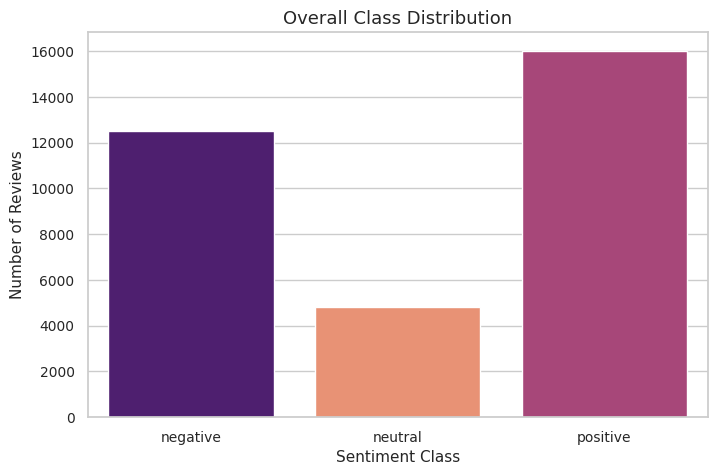

Metric justification:


,metric,why_it_is_reported
0,macro_f1,Treats all classes equally; important when neu...
1,weighted_f1,Reflects overall performance accounting for cl...
2,accuracy,Provides familiar summary metric but insuffici...


PosixPath('/content/outputs/tables/10_metric_justification.csv')

In [12]:
# ============================================================
# CELL 10 — CLASS BALANCE ANALYSIS AND METRIC JUSTIFICATION
# ============================================================

"""
Analyze class balance across splits and justify the use of macro F1 as primary metric.
"""

print_heading("Class balance analysis")

# Overall class distribution
overall_class_balance = (
    df[TARGET_COL]
    .value_counts()
    .reindex(LABEL_ORDER, fill_value=0)
    .reset_index()
)
overall_class_balance.columns = ["sentiment", "count"]
overall_class_balance["percentage"] = (
    overall_class_balance["count"] / overall_class_balance["count"].sum() * 100
).round(2)

print("Overall class distribution:")
display(overall_class_balance)
save_df(overall_class_balance, "08_overall_class_balance.csv")

# Class distribution by split
split_class_balance = (
    df.groupby(["split", TARGET_COL])
      .size()
      .reset_index(name="count")
)
split_class_balance["split"] = pd.Categorical(split_class_balance["split"],
                                              categories=["train", "validation", "test"], ordered=True)
split_class_balance[TARGET_COL] = pd.Categorical(split_class_balance[TARGET_COL],
                                                 categories=LABEL_ORDER, ordered=True)
split_class_balance = split_class_balance.sort_values(["split", TARGET_COL]).reset_index(drop=True)
split_totals = split_class_balance.groupby("split", observed=False)["count"].transform("sum")
split_class_balance["percentage_within_split"] = (
    split_class_balance["count"] / split_totals * 100
).round(2)

print("Class distribution by split:")
display(split_class_balance)
save_df(split_class_balance, "09_split_class_balance.csv")

# Visualize overall class distribution
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x=TARGET_COL, order=LABEL_ORDER, hue=TARGET_COL, dodge=False, palette="magma")
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title("Overall Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")
save_figure("01_overall_class_distribution.png")
plt.show()

# Metric justification
metric_justification = pd.DataFrame({
    "metric": ["macro_f1", "weighted_f1", "accuracy"],
    "why_it_is_reported": [
        "Treats all classes equally; important when neutral class is harder to classify.",
        "Reflects overall performance accounting for class support differences.",
        "Provides familiar summary metric but insufficient alone."
    ]
})
print("Metric justification:")
display(metric_justification)
save_df(metric_justification, "10_metric_justification.csv")


EDA linked to modelling decisions


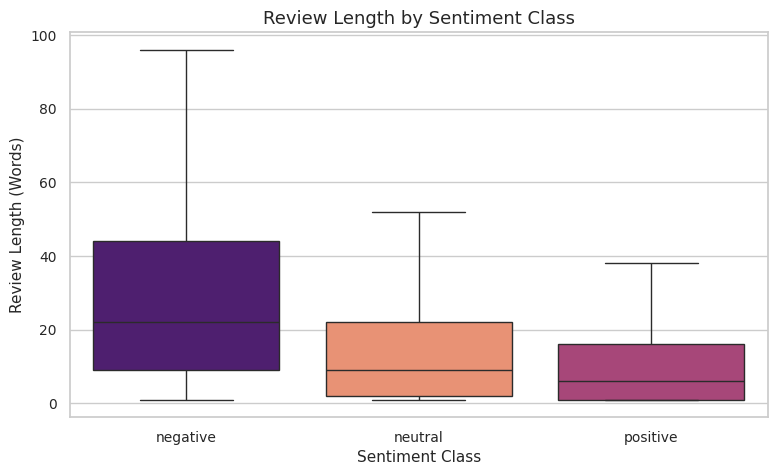

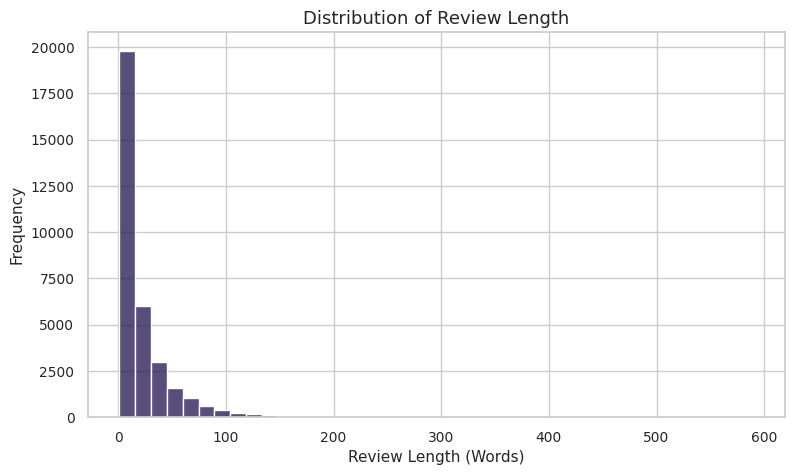

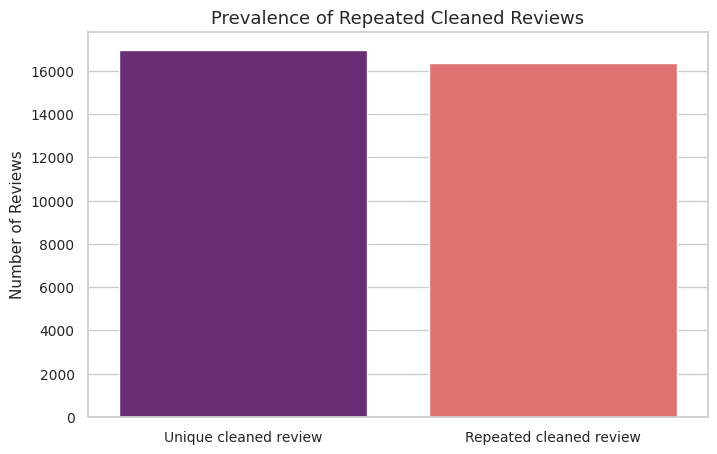

,observation,why_it_matters_for_modelling
0,Review length varies noticeably across examples.,Suggests some sentiment classes may be easier ...
1,Very short reviews are common in the dataset.,Helps explain neutral-class ambiguity and clas...
2,Repeated cleaned reviews are present and non-t...,Supports grouped splitting to reduce duplicate...


PosixPath('/content/outputs/tables/11_eda_modelling_link_summary.csv')

In [13]:
# ============================================================
# CELL 11 — EDA PLOTS LINKED TO MODELLING DECISIONS
# ============================================================

"""
Create analytical EDA plots to justify modeling choices.
"""

print_heading("EDA linked to modelling decisions")

# Plot 1 — Review length by sentiment
plt.figure(figsize=(9,5))
ax = sns.boxplot(data=df, x=TARGET_COL, y="review_length_words",
                 order=LABEL_ORDER, hue=TARGET_COL, dodge=False,
                 palette="magma", showfliers=False)
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title("Review Length by Sentiment Class")
plt.xlabel("Sentiment Class")
plt.ylabel("Review Length (Words)")
save_figure("02_review_length_by_sentiment.png")
plt.show()

# Plot 2 — Distribution of review length
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="review_length_words", bins=40)
plt.title("Distribution of Review Length")
plt.xlabel("Review Length (Words)")
plt.ylabel("Frequency")
save_figure("03_review_length_distribution.png")
plt.show()

# Plot 3 — Duplicate text prevalence
duplicate_summary = df["duplicate_text_flag"].value_counts().rename_axis("duplicate_flag").reset_index(name="count")
duplicate_summary["label"] = duplicate_summary["duplicate_flag"].map({0: "Unique cleaned review", 1: "Repeated cleaned review"})
duplicate_summary["label"] = pd.Categorical(duplicate_summary["label"], categories=["Unique cleaned review","Repeated cleaned review"], ordered=True)
duplicate_summary = duplicate_summary.sort_values("label").reset_index(drop=True)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=duplicate_summary, x="label", y="count", hue="label", dodge=False, palette="magma")
if ax.legend_ is not None:
    ax.legend_.remove()
plt.title("Prevalence of Repeated Cleaned Reviews")
plt.xlabel("")
plt.ylabel("Number of Reviews")
save_figure("04_duplicate_review_prevalence.png")
plt.show()

# Analytical EDA summary
eda_modelling_link_summary = pd.DataFrame({
    "observation": [
        "Review length varies noticeably across examples.",
        "Very short reviews are common in the dataset.",
        "Repeated cleaned reviews are present and non-trivial."
    ],
    "why_it_matters_for_modelling": [
        "Suggests some sentiment classes may be easier or harder depending on text richness.",
        "Helps explain neutral-class ambiguity and classification difficulty.",
        "Supports grouped splitting to reduce duplicate-text leakage."
    ]
})
display(eda_modelling_link_summary)
save_df(eda_modelling_link_summary, "11_eda_modelling_link_summary.csv")


Token length analysis for DistilBERT


Token indices sequence length is longer than the specified maximum sequence length for this model (588 > 512). Running this sequence through the model will result in indexing errors


Token length summary:


,statistic,value
0,min,1
1,25th_percentile,3
2,50th_percentile_median,12
3,75th_percentile,30
4,90th_percentile,61
5,95th_percentile,86
6,99th_percentile,168
7,max,642


Transformer sequence length decision:


,checkpoint,chosen_max_len,decision_rule,raw_95th_percentile_value
0,distilbert-base-uncased,96,Approximate 95th-percentile token-length coverage,86


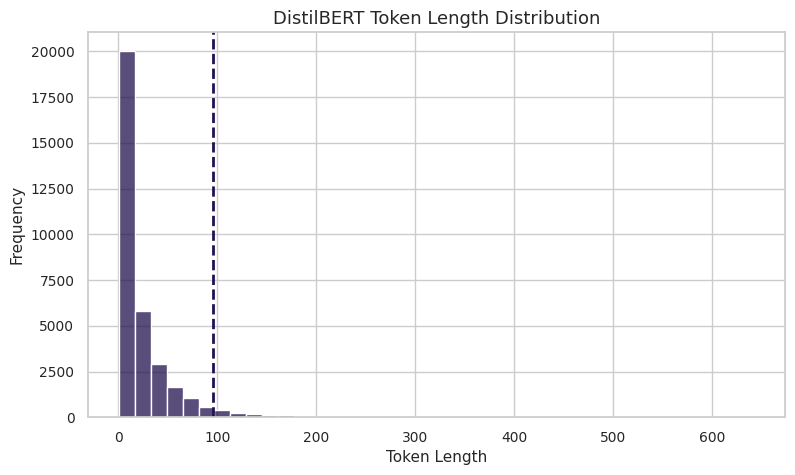

In [14]:
# ============================================================
# CELL 12 — TOKEN LENGTH ANALYSIS FOR DISTILBERT
# ============================================================

"""
Measure token-length distribution with DistilBERT tokenizer to choose max sequence length empirically.
"""

print_heading("Token length analysis for DistilBERT")

DISTILBERT_CHECKPOINT = "distilbert-base-uncased"
distilbert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_CHECKPOINT)

token_lengths = df[TEXT_COL_CLEAN].astype(str).apply(
    lambda text: len(distilbert_tokenizer.encode(text, add_special_tokens=False))
)
df["distilbert_token_length"] = token_lengths

token_length_summary = pd.DataFrame({
    "statistic": ["min","25th_percentile","50th_percentile_median","75th_percentile","90th_percentile","95th_percentile","99th_percentile","max"],
    "value": [
        int(token_lengths.min()),
        int(token_lengths.quantile(0.25)),
        int(token_lengths.quantile(0.50)),
        int(token_lengths.quantile(0.75)),
        int(token_lengths.quantile(0.90)),
        int(token_lengths.quantile(0.95)),
        int(token_lengths.quantile(0.99)),
        int(token_lengths.max())
    ]
})
print("Token length summary:")
display(token_length_summary)
save_df(token_length_summary, "12_distilbert_token_length_summary.csv")

raw_max_len = int(token_lengths.quantile(0.95))
if raw_max_len <= 64: MAX_LEN = 64
elif raw_max_len <= 96: MAX_LEN = 96
elif raw_max_len <= 128: MAX_LEN = 128
else: MAX_LEN = min(160, raw_max_len)

max_len_decision = pd.DataFrame({
    "checkpoint": [DISTILBERT_CHECKPOINT],
    "chosen_max_len": [MAX_LEN],
    "decision_rule": ["Approximate 95th-percentile token-length coverage"],
    "raw_95th_percentile_value": [raw_max_len]
})
print("Transformer sequence length decision:")
display(max_len_decision)
save_df(max_len_decision, "13_transformer_max_length_decision.csv")

# Token-length distribution plot
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="distilbert_token_length", bins=40)
plt.axvline(MAX_LEN, linestyle="--", linewidth=2)
plt.title("DistilBERT Token Length Distribution")
plt.xlabel("Token Length")
plt.ylabel("Frequency")
save_figure("05_distilbert_token_length_distribution.png")
plt.show()

In [15]:
# ============================================================
# CELL 13 — REUSABLE EVALUATION HELPERS
# ============================================================

"""
Define reusable evaluation functions for metrics, results rows, confusion matrices, and bootstrap confidence intervals.
"""

print_heading("Preparing reusable evaluation functions")

def compute_classification_metrics(y_true, y_pred) -> dict:
    """
    Compute key multiclass metrics: accuracy, macro/weighted precision, recall, F1.
    """
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall": float(weighted_r),
        "weighted_f1": float(weighted_f1)
    }

def build_results_row(model_name: str, y_true, y_pred, runtime_seconds: float=np.nan, comments: str="") -> dict:
    """
    Convert metrics into a single summary row for comparison.
    """
    metrics = compute_classification_metrics(y_true, y_pred)
    return {
        "model": model_name,
        "accuracy": round(metrics["accuracy"],4),
        "macro_precision": round(metrics["macro_precision"],4),
        "macro_recall": round(metrics["macro_recall"],4),
        "macro_f1": round(metrics["macro_f1"],4),
        "weighted_precision": round(metrics["weighted_precision"],4),
        "weighted_recall": round(metrics["weighted_recall"],4),
        "weighted_f1": round(metrics["weighted_f1"],4),
        "runtime_seconds": round(runtime_seconds,2) if pd.notna(runtime_seconds) else np.nan,
        "comments": comments
    }

def display_confusion_matrix(y_true, y_pred, title: str, filename: str) -> None:
    """
    Plot and save a confusion matrix using fixed class order.
    """
    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    plt.figure(figsize=(6.5,5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="magma", xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, cbar=True)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    save_figure(filename)
    plt.show()

def bootstrap_macro_f1_ci(y_true, y_pred, n_bootstrap: int=300, seed: int=42) -> dict:
    """
    Estimate bootstrap confidence interval for macro F1.
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    scores = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        indices = rng.integers(0, n, size=n)
        score = f1_score(y_true[indices], y_pred[indices], average="macro", zero_division=0)
        scores.append(score)
    return {
        "bootstrap_macro_f1_mean": round(float(np.mean(scores)),4),
        "bootstrap_macro_f1_ci_lower": round(float(np.percentile(scores,2.5)),4),
        "bootstrap_macro_f1_ci_upper": round(float(np.percentile(scores,97.5)),4)
    }

print("Evaluation helpers are ready.")


Preparing reusable evaluation functions
Evaluation helpers are ready.



Training and evaluating dummy baseline


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,Dummy Baseline (Validation),0.4219,0.1406,0.3333,0.1978,0.178,0.4219,0.2503,0.01,Majority-class reference baseline.
1,Dummy Baseline (Test),0.4347,0.1449,0.3333,0.2020,0.189,0.4347,0.2634,0.01,Reference baseline for comparison.


,label,precision,recall,f1-score,support
0,negative,0.000000,0.000000,0.000000,1753.000000
1,neutral,0.000000,0.000000,0.000000,545.000000
2,positive,0.434686,1.000000,0.605967,1767.000000
3,accuracy,0.434686,0.434686,0.434686,0.434686
4,macro avg,0.144895,0.333333,0.201989,4065.000000
5,weighted avg,0.188952,0.434686,0.263406,4065.000000


,bootstrap_macro_f1_mean,bootstrap_macro_f1_ci_lower,bootstrap_macro_f1_ci_upper
0,0.2017,0.1968,0.2069


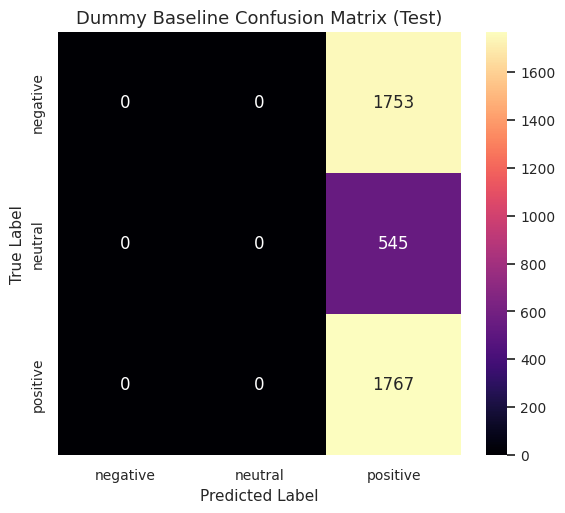

In [16]:
# ============================================================
# CELL 14 — DUMMY BASELINE MODEL
# ============================================================

"""
Train and evaluate a majority-class dummy baseline for reference.
Provides a trivial benchmark to compare all real models against.
"""

print_heading("Training and evaluating dummy baseline")

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_start_time = time.time()
dummy_model.fit(X_train.to_frame(name=TEXT_COL_CLEAN), y_train)
dummy_runtime = time.time() - dummy_start_time

dummy_val_pred = dummy_model.predict(X_val.to_frame(name=TEXT_COL_CLEAN))
dummy_test_pred = dummy_model.predict(X_test.to_frame(name=TEXT_COL_CLEAN))

# Summarize results
dummy_results_df = pd.DataFrame([
    build_results_row(
        model_name="Dummy Baseline (Validation)",
        y_true=y_val,
        y_pred=dummy_val_pred,
        runtime_seconds=dummy_runtime,
        comments="Majority-class reference baseline."
    ),
    build_results_row(
        model_name="Dummy Baseline (Test)",
        y_true=y_test,
        y_pred=dummy_test_pred,
        runtime_seconds=dummy_runtime,
        comments="Reference baseline for comparison."
    )
])
display(dummy_results_df)
save_df(dummy_results_df, "14_dummy_baseline_results.csv")

# Classification report
dummy_report_df = pd.DataFrame(
    classification_report(y_test, dummy_test_pred,
                          labels=LABEL_ORDER, output_dict=True, zero_division=0)
).transpose().reset_index().rename(columns={"index":"label"})
display(dummy_report_df)
save_df(dummy_report_df, "15_dummy_baseline_classification_report.csv")

# Bootstrap CI for macro F1
dummy_ci_df = pd.DataFrame([bootstrap_macro_f1_ci(y_test, dummy_test_pred, n_bootstrap=300, seed=RANDOM_STATE)])
display(dummy_ci_df)
save_df(dummy_ci_df, "16_dummy_baseline_macro_f1_ci.csv")

# Confusion matrix
display_confusion_matrix(y_test, dummy_test_pred,
                         title="Dummy Baseline Confusion Matrix (Test)",
                         filename="06_dummy_baseline_confusion_matrix.png")

In [17]:
# ============================================================
# CELL 15 — CLASSICAL MODEL PIPELINES AND GROUP-AWARE CV
# ============================================================

"""
Define classical text-classification pipelines and group-aware cross-validation.
Avoids leakage by ensuring duplicate cleaned reviews stay in the same fold.
"""

print_heading("Preparing classical pipelines with group-aware CV")

train_groups = train_df[TEXT_COL_CLEAN].astype(str).reset_index(drop=True)
cv_strategy = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

base_tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1,2),
                             min_df=3, max_df=0.90, max_features=15000,
                             sublinear_tf=True)

classical_pipelines = {
    "Logistic Regression": Pipeline([("tfidf", base_tfidf),
                                     ("model", LogisticRegression(max_iter=2500,
                                                                 class_weight="balanced",
                                                                 random_state=RANDOM_STATE))]),
    "Multinomial Naive Bayes": Pipeline([("tfidf", base_tfidf),
                                        ("model", MultinomialNB())]),
    "Linear SVM": Pipeline([("tfidf", base_tfidf),
                            ("model", LinearSVC(C=1.0, class_weight="balanced",
                                                random_state=RANDOM_STATE))]),
    "SGD Classifier": Pipeline([("tfidf", base_tfidf),
                                ("model", SGDClassifier(loss="hinge", alpha=1e-4,
                                                        max_iter=2000, tol=1e-3,
                                                        class_weight="balanced",
                                                        random_state=RANDOM_STATE))])
}

# Classical model notes
classical_model_notes = pd.DataFrame({
    "model": list(classical_pipelines.keys()),
    "role_in_comparison": [
        "Strong linear baseline with interpretable coefficients.",
        "Fast probabilistic lexical baseline.",
        "Linear margin-based strong baseline for text.",
        "Fast large-scale linear classifier for sparse text."
    ],
    "cv_strategy": ["StratifiedGroupKFold"]*len(classical_pipelines)
})
display(classical_model_notes)
save_df(classical_model_notes, "17_classical_model_notes.csv")


Preparing classical pipelines with group-aware CV


,model,role_in_comparison,cv_strategy
0,Logistic Regression,Strong linear baseline with interpretable coef...,StratifiedGroupKFold
1,Multinomial Naive Bayes,Fast probabilistic lexical baseline.,StratifiedGroupKFold
2,Linear SVM,Linear margin-based strong baseline for text.,StratifiedGroupKFold
3,SGD Classifier,Fast large-scale linear classifier for sparse ...,StratifiedGroupKFold


PosixPath('/content/outputs/tables/17_classical_model_notes.csv')


Group-aware CV benchmarking for classical models


,model,cv_macro_f1_mean,cv_macro_f1_std,cv_macro_f1_min,cv_macro_f1_max,cv_runtime_seconds
0,Logistic Regression,0.7120,0.0244,0.6872,0.7451,8.18
1,SGD Classifier,0.6348,0.0464,0.5694,0.6712,6.94
2,Linear SVM,0.6327,0.0467,0.5667,0.6696,8.06
3,Multinomial Naive Bayes,0.5578,0.0073,0.5525,0.5680,6.95


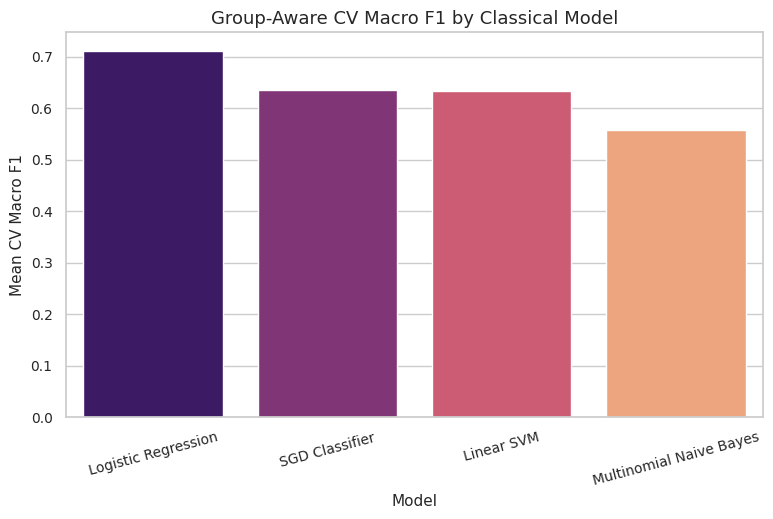

In [18]:
# ============================================================
# CELL 16 — GROUP-AWARE CROSS-VALIDATION BENCHMARKING
# ============================================================

"""
Benchmark classical pipelines using group-aware CV before tuning.
Provides trustworthy mean and std estimates of macro F1.
"""

print_heading("Group-aware CV benchmarking for classical models")

cv_rows = []
for model_name, pipeline in classical_pipelines.items():
    start_time = time.time()
    cv_scores = cross_val_score(
        estimator=pipeline,
        X=X_train, y=y_train, groups=train_groups,
        cv=cv_strategy, scoring="f1_macro", n_jobs=-1
    )
    elapsed = time.time() - start_time
    cv_rows.append({
        "model": model_name,
        "cv_macro_f1_mean": round(float(cv_scores.mean()),4),
        "cv_macro_f1_std": round(float(cv_scores.std()),4),
        "cv_macro_f1_min": round(float(cv_scores.min()),4),
        "cv_macro_f1_max": round(float(cv_scores.max()),4),
        "cv_runtime_seconds": round(elapsed,2)
    })

cv_benchmark_df = pd.DataFrame(cv_rows).sort_values("cv_macro_f1_mean", ascending=False).reset_index(drop=True)
display(cv_benchmark_df)
save_df(cv_benchmark_df, "18_classical_cv_benchmark_summary.csv")

# Visual comparison
plt.figure(figsize=(9,5))
ax = sns.barplot(data=cv_benchmark_df, x="model", y="cv_macro_f1_mean", hue="model", dodge=False, palette="magma")
if ax.legend_ is not None: ax.legend_.remove()
plt.title("Group-Aware CV Macro F1 by Classical Model")
plt.xlabel("Model"); plt.ylabel("Mean CV Macro F1")
plt.xticks(rotation=15)
save_figure("07_classical_cv_macro_f1_comparison.png")
plt.show()

In [19]:
# ============================================================
# CELL 17 — TARGETED HYPERPARAMETER SEARCH SPACES
# ============================================================

"""
Define focused hyperparameter search spaces for classical models.
Keeps tuning meaningful but runtime practical.
"""

print_heading("Preparing targeted hyperparameter search spaces")

param_distributions = {
    "Logistic Regression": {
        "tfidf__ngram_range": [(1,1),(1,2)],
        "tfidf__min_df": [2,3,5],
        "tfidf__max_df": [0.85,0.90],
        "tfidf__max_features": [12000,15000,20000],
        "model__C": [0.25,0.5,1.0,2.0,5.0]
    },
    "Multinomial Naive Bayes": {
        "tfidf__ngram_range": [(1,1),(1,2)],
        "tfidf__min_df": [2,3,5],
        "tfidf__max_df": [0.85,0.90],
        "tfidf__max_features": [12000,15000,20000],
        "model__alpha": [0.05,0.1,0.5,1.0,2.0]
    },
    "Linear SVM": {
        "tfidf__ngram_range": [(1,1),(1,2)],
        "tfidf__min_df": [2,3,5],
        "tfidf__max_df": [0.85,0.90],
        "tfidf__max_features": [12000,15000,20000],
        "model__C": [0.25,0.5,1.0,2.0,5.0]
    },
    "SGD Classifier": {
        "tfidf__ngram_range": [(1,1),(1,2)],
        "tfidf__min_df": [2,3,5],
        "tfidf__max_df": [0.85,0.90],
        "tfidf__max_features": [12000,15000,20000],
        "model__loss": ["hinge","log_loss"],
        "model__alpha": [1e-5,5e-5,1e-4,5e-4]
    }
}

search_space_summary_df = pd.DataFrame([
    {"model": model_name, "number_of_hyperparameters_tuned": len(search_space),
     "tuning_strategy":"RandomizedSearchCV with macro F1"}
    for model_name, search_space in param_distributions.items()
])
display(search_space_summary_df)
save_df(search_space_summary_df, "19_hyperparameter_search_space_summary.csv")


Preparing targeted hyperparameter search spaces


,model,number_of_hyperparameters_tuned,tuning_strategy
0,Logistic Regression,5,RandomizedSearchCV with macro F1
1,Multinomial Naive Bayes,5,RandomizedSearchCV with macro F1
2,Linear SVM,5,RandomizedSearchCV with macro F1
3,SGD Classifier,6,RandomizedSearchCV with macro F1


PosixPath('/content/outputs/tables/19_hyperparameter_search_space_summary.csv')

In [20]:
# ============================================================
# CELL 18 — GROUP-AWARE HYPERPARAMETER TUNING FOR CLASSICAL MODELS
# ============================================================

"""
Tune each classical model using RandomizedSearchCV with macro F1 on training split.
Ensures no duplicate cleaned reviews leak across CV folds.
"""

print_heading("Group-aware hyperparameter tuning for classical models")

tuned_models = {}
tuning_rows = {}
model_n_iter = {"Logistic Regression":8, "Multinomial Naive Bayes":8, "Linear SVM":8, "SGD Classifier":8}

for model_name, pipeline in classical_pipelines.items():
    print(f"Tuning: {model_name}")
    start_time = time.time()

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions[model_name],
        n_iter=model_n_iter[model_name],
        scoring="f1_macro",
        cv=cv_strategy,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
        refit=True
    )

    search.fit(X_train, y_train, groups=train_groups)
    tuned_models[model_name] = search.best_estimator_

    tuning_rows[model_name] = {
        "best_cv_macro_f1": round(float(search.best_score_),4),
        "tuning_runtime_seconds": round(time.time()-start_time,2),
        "best_params": str(search.best_params_)
    }

tuning_summary_df = pd.DataFrame(tuning_rows).T.sort_values(by="best_cv_macro_f1",ascending=False).reset_index().rename(columns={"index":"model"})
display(tuning_summary_df)
save_df(tuning_summary_df, "20_classical_tuning_summary.csv")


Group-aware hyperparameter tuning for classical models
Tuning: Logistic Regression
Tuning: Multinomial Naive Bayes
Tuning: Linear SVM
Tuning: SGD Classifier


,model,best_cv_macro_f1,tuning_runtime_seconds,best_params
0,Logistic Regression,0.7142,19.88,"{'tfidf__ngram_range': (1, 1), 'tfidf__min_df'..."
1,Linear SVM,0.6401,12.29,"{'tfidf__ngram_range': (1, 1), 'tfidf__min_df'..."
2,SGD Classifier,0.6387,6.32,"{'tfidf__ngram_range': (1, 1), 'tfidf__min_df'..."
3,Multinomial Naive Bayes,0.6012,6.7,"{'tfidf__ngram_range': (1, 2), 'tfidf__min_df'..."


PosixPath('/content/outputs/tables/20_classical_tuning_summary.csv')

In [21]:
# ============================================================
# CELL 19 — VALIDATION-SET COMPARISON OF TUNED CLASSICAL MODELS
# ============================================================

"""
Evaluate tuned classical models on validation split to select the best model.
"""

print_heading("Validation comparison of tuned classical models")

validation_rows = []
validation_predictions = {}

for model_name, model in tuned_models.items():
    start_time = time.time()
    val_pred = model.predict(X_val)
    elapsed = time.time() - start_time
    validation_predictions[model_name] = val_pred

    validation_rows.append(build_results_row(
        model_name=f"{model_name} (Validation)",
        y_true=y_val,
        y_pred=val_pred,
        runtime_seconds=elapsed,
        comments="Tuned model evaluated on validation split."
    ))

validation_results_df = pd.DataFrame(validation_rows).sort_values(by="macro_f1",ascending=False).reset_index(drop=True)
display(validation_results_df)
save_df(validation_results_df, "21_validation_results_tuned_classical_models.csv")

best_classical_model_name = validation_results_df.loc[0,"model"].replace(" (Validation)","")
best_classical_model = tuned_models[best_classical_model_name]

best_model_note_df = pd.DataFrame({
    "selected_best_classical_model":[best_classical_model_name],
    "selection_basis":["Highest validation macro F1 among tuned classical models"]
})
display(best_model_note_df)
save_df(best_model_note_df, "22_best_classical_model_selection_note.csv")


Validation comparison of tuned classical models


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,Logistic Regression (Validation),0.7293,0.6601,0.6636,0.6564,0.7619,0.7293,0.7420,0.08,Tuned model evaluated on validation split.
1,SGD Classifier (Validation),0.7518,0.6473,0.6435,0.6444,0.7411,0.7518,0.7458,0.08,Tuned model evaluated on validation split.
2,Linear SVM (Validation),0.7462,0.6405,0.6379,0.6385,0.7364,0.7462,0.7408,0.08,Tuned model evaluated on validation split.
3,Multinomial Naive Bayes (Validation),0.7636,0.6598,0.6230,0.6169,0.7307,0.7636,0.7352,0.14,Tuned model evaluated on validation split.


,selected_best_classical_model,selection_basis
0,Logistic Regression,Highest validation macro F1 among tuned classi...


PosixPath('/content/outputs/tables/22_best_classical_model_selection_note.csv')

In [22]:
# ============================================================
# CELL 20 — CLASSICAL MODEL SUMMARY TABLE
# ============================================================

"""
Combine cross-validation, tuning, and validation results into a single summary table.
Provides a transparent overview for reporting and model comparison.
"""

print_heading("Building classical model summary table")

# Prepare CV, tuning, and validation summaries
cv_summary = cv_benchmark_df.copy()
tuning_summary = tuning_summary_df.copy()[["model","best_cv_macro_f1","tuning_runtime_seconds","best_params"]]

validation_summary = validation_results_df.copy()
validation_summary["model"] = validation_summary["model"].str.replace(" (Validation)", "", regex=False)
validation_summary = validation_summary[[
    "model","accuracy","macro_precision","macro_recall","macro_f1","weighted_f1","runtime_seconds"
]].rename(columns={
    "accuracy": "validation_accuracy",
    "macro_precision": "validation_macro_precision",
    "macro_recall": "validation_macro_recall",
    "macro_f1": "validation_macro_f1",
    "weighted_f1": "validation_weighted_f1",
    "runtime_seconds": "validation_inference_seconds"
})

# Merge all summaries
classical_summary_table = cv_summary.merge(tuning_summary, on="model", how="left")\
                                    .merge(validation_summary, on="model", how="left")\
                                    .sort_values(by="validation_macro_f1", ascending=False)\
                                    .reset_index(drop=True)

print("Combined classical model summary:")
display(classical_summary_table)
save_df(classical_summary_table, "23_classical_model_summary_table.csv")

# Interpretability notes
interpretability_notes_df = pd.DataFrame({
    "model": ["Logistic Regression","Multinomial Naive Bayes","Linear SVM"],
    "interpretability_level": ["High","Moderate","Moderate to High"],
    "practical_note": [
        "Strong linear baseline with interpretable coefficients.",
        "Fast lexical-probability baseline.",
        "Strong text baseline with good performance and efficiency."
    ]
})
display(interpretability_notes_df)
save_df(interpretability_notes_df, "24_classical_model_interpretability_notes.csv")


Building classical model summary table
Combined classical model summary:


,model,cv_macro_f1_mean,cv_macro_f1_std,cv_macro_f1_min,cv_macro_f1_max,cv_runtime_seconds,best_cv_macro_f1,tuning_runtime_seconds,best_params,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_weighted_f1,validation_inference_seconds
0,Logistic Regression,0.7120,0.0244,0.6872,0.7451,8.18,0.7142,19.88,"{'tfidf__ngram_range': (1, 1), 'tfidf__min_df'...",0.7293,0.6601,0.6636,0.6564,0.7420,0.08
1,SGD Classifier,0.6348,0.0464,0.5694,0.6712,6.94,0.6387,6.32,"{'tfidf__ngram_range': (1, 1), 'tfidf__min_df'...",0.7518,0.6473,0.6435,0.6444,0.7458,0.08
2,Linear SVM,0.6327,0.0467,0.5667,0.6696,8.06,0.6401,12.29,"{'tfidf__ngram_range': (1, 1), 'tfidf__min_df'...",0.7462,0.6405,0.6379,0.6385,0.7408,0.08
3,Multinomial Naive Bayes,0.5578,0.0073,0.5525,0.5680,6.95,0.6012,6.7,"{'tfidf__ngram_range': (1, 2), 'tfidf__min_df'...",0.7636,0.6598,0.6230,0.6169,0.7352,0.14


,model,interpretability_level,practical_note
0,Logistic Regression,High,Strong linear baseline with interpretable coef...
1,Multinomial Naive Bayes,Moderate,Fast lexical-probability baseline.
2,Linear SVM,Moderate to High,Strong text baseline with good performance and...


PosixPath('/content/outputs/tables/24_classical_model_interpretability_notes.csv')

In [23]:
# ============================================================
# CELL 21 — COMBINE TRAIN + VALIDATION FOR FINAL CLASSICAL REFIT
# ============================================================

"""
Combine training and validation splits for final refit of classical models before test evaluation.
"""

print_heading("Preparing combined training set for final classical evaluation")

X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
train_val_groups = pd.concat([train_df[TEXT_COL_CLEAN], val_df[TEXT_COL_CLEAN]], axis=0).reset_index(drop=True)

train_val_summary_df = pd.DataFrame({
    "dataset": ["train","validation","combined_train_validation","test"],
    "rows": [len(X_train), len(X_val), len(X_train_val), len(X_test)],
    "role": [
        "Initial fitting and cross-validation",
        "Model selection and comparison",
        "Final classical refit before held-out testing",
        "Untouched final evaluation set"
    ]
})
display(train_val_summary_df)
save_df(train_val_summary_df, "25_train_validation_combined_summary.csv")

print("Combined non-test training set prepared successfully.")


Preparing combined training set for final classical evaluation


,dataset,rows,role
0,train,25199,Initial fitting and cross-validation
1,validation,4082,Model selection and comparison
2,combined_train_validation,29281,Final classical refit before held-out testing
3,test,4065,Untouched final evaluation set


Combined non-test training set prepared successfully.


In [24]:
# ============================================================
# CELL 22 — FINAL REFIT AND TEST EVALUATION
# ============================================================

"""
Clone and refit each tuned classical model on combined train + validation data.
Evaluate each model once on untouched test set.
"""

print_heading("Final refit and held-out test evaluation for classical models")

final_classical_models = {}
final_test_predictions = {}
final_test_rows = []

for model_name, tuned_model in tuned_models.items():
    final_model = clone(tuned_model)
    fit_start_time = time.time()
    final_model.fit(X_train_val, y_train_val)
    fit_elapsed = time.time() - fit_start_time

    pred_start_time = time.time()
    test_pred = final_model.predict(X_test)
    pred_elapsed = time.time() - pred_start_time

    final_classical_models[model_name] = final_model
    final_test_predictions[model_name] = test_pred

    final_test_rows.append(build_results_row(
        model_name=f"{model_name} (Test)",
        y_true=y_test,
        y_pred=test_pred,
        runtime_seconds=fit_elapsed + pred_elapsed,
        comments="Refit on train+validation, evaluated on held-out test set."
    ))

final_test_results_df = pd.DataFrame(final_test_rows)\
                        .sort_values(by="macro_f1", ascending=False)\
                        .reset_index(drop=True)

print("Final held-out test results for classical models:")
display(final_test_results_df)
save_df(final_test_results_df, "26_final_classical_test_results.csv")


Final refit and held-out test evaluation for classical models
Final held-out test results for classical models:


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,Logistic Regression (Test),0.7383,0.6660,0.6736,0.6643,0.7704,0.7383,0.7509,15.48,"Refit on train+validation, evaluated on held-o..."
1,SGD Classifier (Test),0.7542,0.6607,0.6614,0.6609,0.7564,0.7542,0.7552,0.81,"Refit on train+validation, evaluated on held-o..."
2,Linear SVM (Test),0.7567,0.6588,0.6552,0.6566,0.7507,0.7567,0.7534,1.76,"Refit on train+validation, evaluated on held-o..."
3,Multinomial Naive Bayes (Test),0.7658,0.6769,0.6319,0.6327,0.7409,0.7658,0.7432,1.36,"Refit on train+validation, evaluated on held-o..."


PosixPath('/content/outputs/tables/26_final_classical_test_results.csv')

In [25]:
# ============================================================
# CELL 23 — STABILITY CHECK FOR BEST CLASSICAL MODEL
# ============================================================

"""
Check stability of best classical model across a few random seeds to ensure results are not seed-dependent.
"""

print_heading("Stability check for the best classical model")

stability_seeds = [11,22,33]
stability_rows = []

best_classical_base_name = best_classical_model_name
best_pipeline = tuned_models[best_classical_base_name]

for seed in stability_seeds:
    candidate = clone(best_pipeline)
    if "model" in candidate.named_steps:
        inner_model = candidate.named_steps["model"]
        if hasattr(inner_model,"random_state"):
            inner_model.random_state = seed

    start_time = time.time()
    candidate.fit(X_train, y_train)
    val_pred = candidate.predict(X_val)
    elapsed = time.time() - start_time

    stability_rows.append(build_results_row(
        model_name=f"{best_classical_base_name} | seed={seed}",
        y_true=y_val,
        y_pred=val_pred,
        runtime_seconds=elapsed,
        comments="Small repeated-seed stability check on validation split."
    ))

classical_stability_df = pd.DataFrame(stability_rows).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)
display(classical_stability_df)
save_df(classical_stability_df, "28a_best_classical_model_seed_stability.csv")

classical_stability_summary_df = pd.DataFrame({
    "model": [best_classical_base_name],
    "macro_f1_mean_across_seeds": [round(classical_stability_df["macro_f1"].mean(),4)],
    "macro_f1_std_across_seeds": [round(classical_stability_df["macro_f1"].std(ddof=0),4)],
    "n_seeds_tested": [len(stability_seeds)]
})
display(classical_stability_summary_df)
save_df(classical_stability_summary_df, "28b_best_classical_model_seed_stability_summary.csv")


Stability check for the best classical model


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,Logistic Regression | seed=11,0.7293,0.6601,0.6636,0.6564,0.7619,0.7293,0.742,11.64,Small repeated-seed stability check on validat...
1,Logistic Regression | seed=22,0.7293,0.6601,0.6636,0.6564,0.7619,0.7293,0.742,11.48,Small repeated-seed stability check on validat...
2,Logistic Regression | seed=33,0.7293,0.6601,0.6636,0.6564,0.7619,0.7293,0.742,11.18,Small repeated-seed stability check on validat...


,model,macro_f1_mean_across_seeds,macro_f1_std_across_seeds,n_seeds_tested
0,Logistic Regression,0.6564,0.0,3


PosixPath('/content/outputs/tables/28b_best_classical_model_seed_stability_summary.csv')


Confusion matrices for top classical models


,rank,model
0,1,Logistic Regression
1,2,SGD Classifier
2,3,Linear SVM


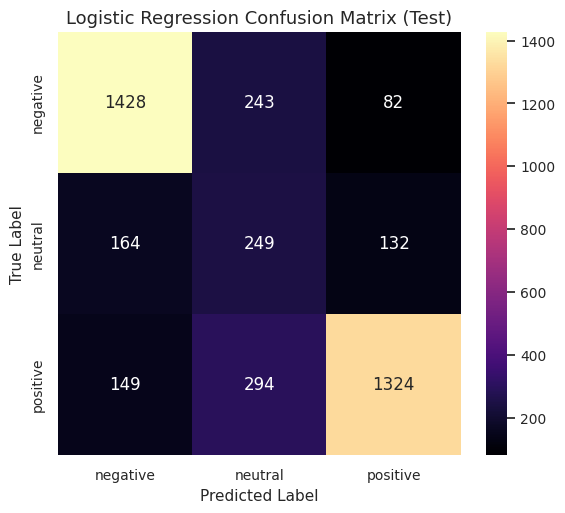

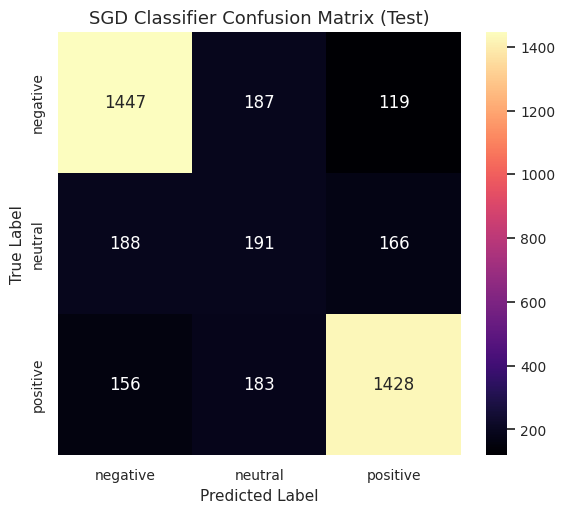

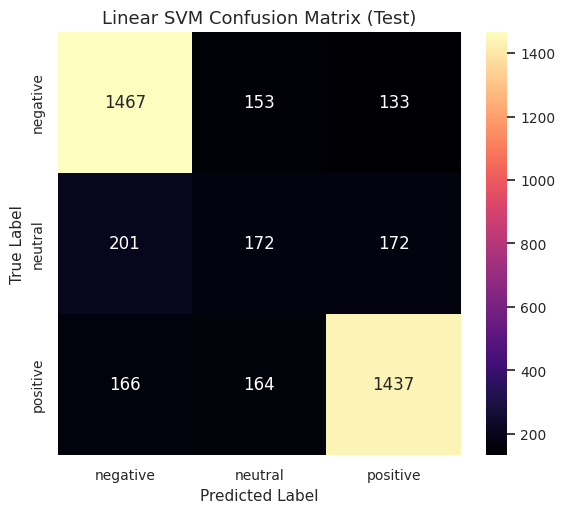

In [26]:
# ============================================================
# CELL 24 — CONFUSION MATRICES FOR TOP CLASSICAL MODELS
# ============================================================

"""
Visualise confusion matrices for the top 3 classical models to examine per-class behaviour.
"""

print_heading("Confusion matrices for top classical models")

# Select top 3 models by held-out macro F1
top_classical_model_names = (
    final_test_results_df["model"]
    .str.replace(" (Test)", "", regex=False)
    .head(3)
    .tolist()
)

top_models_summary_df = pd.DataFrame({
    "rank": range(1, len(top_classical_model_names)+1),
    "model": top_classical_model_names
})
display(top_models_summary_df)
save_df(top_models_summary_df, "29_top_classical_models_for_confusion_matrices.csv")

# Plot confusion matrices
for rank, model_name in enumerate(top_classical_model_names, start=1):
    safe_name = model_name.lower().replace(" ", "_")
    display_confusion_matrix(
        y_true=y_test,
        y_pred=final_test_predictions[model_name],
        title=f"{model_name} Confusion Matrix (Test)",
        filename=f"{8+rank:02d}_{safe_name}_confusion_matrix.png"
    )

In [27]:
# ============================================================
# CELL 25 — PER-CLASS TEST PERFORMANCE FOR TOP CLASSICAL MODELS
# ============================================================

"""
Compare per-class precision, recall, and F1 for the top 3 classical models.
Identify hardest classes, especially neutral sentiment.
"""

print_heading("Per-class test performance comparison")

per_class_rows = []

for model_name in top_classical_model_names:
    report_dict = classification_report(y_test, final_test_predictions[model_name],
                                        labels=LABEL_ORDER, output_dict=True, zero_division=0)
    for label in LABEL_ORDER:
        per_class_rows.append({
            "model": model_name,
            "class": label,
            "precision": round(report_dict[label]["precision"],4),
            "recall": round(report_dict[label]["recall"],4),
            "f1_score": round(report_dict[label]["f1-score"],4),
            "support": int(report_dict[label]["support"])
        })

per_class_comparison_df = pd.DataFrame(per_class_rows)
display(per_class_comparison_df)
save_df(per_class_comparison_df, "30_per_class_test_performance_top_classical_models.csv")

# Hardest class summary
hardest_class_summary_df = (
    per_class_comparison_df.groupby("class", as_index=False)["f1_score"]
    .mean().rename(columns={"f1_score":"mean_f1_across_top_models"})
    .sort_values("mean_f1_across_top_models", ascending=True)
    .reset_index(drop=True)
)
display(hardest_class_summary_df)
save_df(hardest_class_summary_df, "31_hardest_class_summary_top_classical_models.csv")


Per-class test performance comparison


,model,class,precision,recall,f1_score,support
0,Logistic Regression,negative,0.8202,0.8146,0.8174,1753
1,Logistic Regression,neutral,0.3168,0.4569,0.3742,545
2,Logistic Regression,positive,0.8609,0.7493,0.8012,1767
3,SGD Classifier,negative,0.8079,0.8254,0.8166,1753
4,SGD Classifier,neutral,0.3405,0.3505,0.3454,545
5,SGD Classifier,positive,0.8336,0.8081,0.8207,1767
6,Linear SVM,negative,0.7999,0.8369,0.8180,1753
7,Linear SVM,neutral,0.3517,0.3156,0.3327,545
8,Linear SVM,positive,0.8249,0.8132,0.8190,1767


,class,mean_f1_across_top_models
0,neutral,0.350767
1,positive,0.813633
2,negative,0.817333


PosixPath('/content/outputs/tables/31_hardest_class_summary_top_classical_models.csv')

In [28]:
# ============================================================
# CELL 26 — INTERPRETABILITY FOR TOP CLASSICAL MODELS
# ============================================================

"""
Extract top influential text features for interpretable linear models
(Logistic Regression, Linear SVM) among top classical models.
"""

print_heading("Interpretability for top classical models")

def extract_top_terms_from_linear_pipeline(pipeline, class_labels, top_n=15):
    """
    Extract top positive terms per class from a fitted linear text pipeline.
    """
    vectorizer = pipeline.named_steps["tfidf"]
    model = pipeline.named_steps["model"]
    if not hasattr(model, "coef_"):
        return None

    feature_names = np.array(vectorizer.get_feature_names_out())
    coef_matrix = model.coef_
    rows = []
    for class_index, class_label in enumerate(class_labels):
        class_coefs = coef_matrix[class_index]
        top_indices = np.argsort(class_coefs)[-top_n:][::-1]
        for rank, idx in enumerate(top_indices, start=1):
            rows.append({
                "class": class_label,
                "rank": rank,
                "term": feature_names[idx],
                "coefficient": round(float(class_coefs[idx]),4)
            })
    return pd.DataFrame(rows)

interpretability_frames = []
for model_name in top_classical_model_names:
    fitted_model = final_classical_models[model_name]
    inner_model = fitted_model.named_steps["model"]
    if hasattr(inner_model,"coef_"):
        top_terms_df = extract_top_terms_from_linear_pipeline(fitted_model, LABEL_ORDER, top_n=15)
        if top_terms_df is not None and not top_terms_df.empty:
            top_terms_df.insert(0,"model",model_name)
            interpretability_frames.append(top_terms_df)

if interpretability_frames:
    interpretability_df = pd.concat(interpretability_frames, ignore_index=True)
    display(interpretability_df)
    save_df(interpretability_df, "32_top_terms_interpretable_classical_models.csv")

    interpretability_summary_df = (
        interpretability_df.groupby(["model","class"], as_index=False)
        .agg(n_terms=("term","count"),
             mean_abs_coefficient=("coefficient", lambda x: round(np.mean(np.abs(x)),4)))
    )
    display(interpretability_summary_df)
    save_df(interpretability_summary_df, "32a_interpretability_summary_top_classical_models.csv")
else:
    interpretability_df = pd.DataFrame()
    print("No coefficient-based interpretability available for selected models.")


Interpretability for top classical models


,model,class,rank,term,coefficient
0,Logistic Regression,negative,1,worst,6.4135
1,Logistic Regression,negative,2,horrible,4.0979
2,Logistic Regression,negative,3,terrible,3.7317
3,Logistic Regression,negative,4,poor,3.3851
4,Logistic Regression,negative,5,not,3.0278
...,...,...,...,...,...
130,Linear SVM,positive,11,quickly,1.4492
131,Linear SVM,positive,12,complaints,1.4341
132,Linear SVM,positive,13,wonderful,1.4238
133,Linear SVM,positive,14,delicious,1.3812


,model,class,n_terms,mean_abs_coefficient
0,Linear SVM,negative,15,1.9615
1,Linear SVM,neutral,15,1.8436
2,Linear SVM,positive,15,1.6209
3,Logistic Regression,negative,15,3.1548
4,Logistic Regression,neutral,15,1.8540
5,Logistic Regression,positive,15,2.8094
6,SGD Classifier,negative,15,5.6200
7,SGD Classifier,neutral,15,4.4011
8,SGD Classifier,positive,15,4.7174


In [29]:
# ============================================================
# CELL 27 — MISCLASSIFIED EXAMPLES AND CORE ERROR TABLES
# ============================================================

"""
Collect misclassified examples for top classical models and build structured tables.
"""

print_heading("Misclassified examples and core error tables")

error_frames = []
for model_name in top_classical_model_names:
    temp = test_df.copy()
    temp["predicted_sentiment"] = final_test_predictions[model_name]
    temp["correct_prediction"] = (temp[TARGET_COL]==temp["predicted_sentiment"]).astype(int)
    temp["model"] = model_name

    keep_cols = [
        "model", TEXT_COL_RAW, TEXT_COL_CLEAN, "rating_num", TARGET_COL,
        "predicted_sentiment", "review_length_words", "question_count",
        "exclamation_count", "encoding_issue_flag", "duplicate_text_flag"
    ]
    available_cols = [c for c in keep_cols if c in temp.columns]
    errors = temp[temp["correct_prediction"]==0][available_cols].copy()
    error_frames.append(errors)

if error_frames:
    all_errors_df = pd.concat(error_frames, ignore_index=True)
    display(all_errors_df.head(20))
    save_df(all_errors_df, "33_top_classical_model_error_examples.csv")

    error_count_summary_df = all_errors_df.groupby("model", as_index=False).size()\
                               .rename(columns={"size":"misclassified_examples"})\
                               .sort_values("misclassified_examples", ascending=False).reset_index(drop=True)
    display(error_count_summary_df)
    save_df(error_count_summary_df, "33a_top_classical_model_error_count_summary.csv")
else:
    all_errors_df = pd.DataFrame()
    print("No misclassified examples found, check data consistency.")


Misclassified examples and core error tables


,model,review_raw,review_clean,rating_num,sentiment,predicted_sentiment,review_length_words,question_count,exclamation_count,encoding_issue_flag,duplicate_text_flag
0,Logistic Regression,Me and my girlfriend came tonight to pick up o...,me and my girlfriend came tonight to pick up o...,3.0,neutral,positive,40,0,0,0,0
1,Logistic Regression,OPEN 24HRS all the darn time!! If there are 2...,open hrs all the darn time if there are hours ...,4.0,positive,negative,83,0,2,0,0
2,Logistic Regression,"Never gotten my order wrong, employees seem to...",never gotten my order wrong employees seem to ...,5.0,positive,negative,37,0,0,0,0
3,Logistic Regression,I ordered 4 happy meals with plain cheeseburge...,i ordered happy meals with plain cheeseburgers...,1.0,negative,neutral,25,0,0,0,0
4,Logistic Regression,"Always busy, sort of slow (but not too slow). ...",always busy sort of slow but not too slow dang...,2.0,negative,neutral,37,0,0,0,0
5,Logistic Regression,Staff is great ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï...,staff is great except for the fat m,1.0,negative,positive,8,0,0,0,0
6,Logistic Regression,"Decent fast food, order occasionally messed up...",decent fast food order occasionally messed up ...,4.0,positive,neutral,9,0,0,0,0
7,Logistic Regression,They canï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿...,they can,1.0,negative,neutral,2,0,0,0,0
8,Logistic Regression,There food is always cold!!! When you ask for ...,there food is always cold when you ask for fre...,1.0,negative,neutral,17,0,3,0,0
9,Logistic Regression,Bussin 10/10 must try again,bussin must try again,5.0,positive,negative,4,0,0,0,0


,model,misclassified_examples
0,Logistic Regression,1064
1,SGD Classifier,999
2,Linear SVM,989


In [30]:
# ============================================================
# CELL 28 — FORMAL ERROR TAXONOMY TEMPLATE AND QUANTIFICATION
# ============================================================

"""
Assign structured error taxonomy to misclassified examples to quantify common failure modes.
"""

print_heading("Formal error taxonomy and quantification")

def assign_error_taxonomy(row) -> str:
    """
    Assign heuristic error category based on text, length, duplication, and encoding.
    """
    text_raw = str(row.get(TEXT_COL_RAW,""))
    text_clean = str(row.get(TEXT_COL_CLEAN,""))
    word_count = int(row.get("review_length_words",0))
    duplicate_flag = int(row.get("duplicate_text_flag",0))
    encoding_flag = int(row.get("encoding_issue_flag",0))
    true_label = str(row.get(TARGET_COL,""))
    pred_label = str(row.get("predicted_sentiment",""))

    if encoding_flag==1: return "spelling_or_encoding_noise"
    if duplicate_flag==1: return "repeated_template_like_review"
    if word_count<=3: return "very_short_review"
    if true_label=="neutral" and pred_label in {"negative","positive"}:
        return "ambiguous_or_weak_neutral_signal"
    if true_label in {"negative","positive"} and pred_label=="neutral":
        return "muted_polarity_or_low_signal"
    if any(term in text_clean for term in ["but","however","although","though"]):
        return "mixed_sentiment"
    if any(term in text_raw.lower() for term in ["yeah right","sure","great job","nice one"]):
        return "possible_sarcasm_or_irony"
    return "general_semantic_confusion"

if not all_errors_df.empty:
    all_errors_df["error_taxonomy"] = all_errors_df.apply(assign_error_taxonomy, axis=1)

    error_taxonomy_summary_df = all_errors_df.groupby(["model","error_taxonomy"], as_index=False)\
                                   .size().rename(columns={"size":"count"})\
                                   .sort_values(["model","count"], ascending=[True,False]).reset_index(drop=True)
    display(error_taxonomy_summary_df)
    save_df(error_taxonomy_summary_df, "34_error_taxonomy_summary_top_classical_models.csv")

    error_taxonomy_overall_df = all_errors_df.groupby("error_taxonomy", as_index=False)\
                                        .size().rename(columns={"size":"count"})\
                                        .sort_values("count", ascending=False).reset_index(drop=True)
    display(error_taxonomy_overall_df)
    save_df(error_taxonomy_overall_df, "34a_error_taxonomy_overall_summary.csv")
else:
    error_taxonomy_summary_df = pd.DataFrame()
    print("Error taxonomy not created because the error table is empty.")


Formal error taxonomy and quantification


,model,error_taxonomy,count
0,Linear SVM,repeated_template_like_review,300
1,Linear SVM,ambiguous_or_weak_neutral_signal,243
2,Linear SVM,muted_polarity_or_low_signal,194
3,Linear SVM,general_semantic_confusion,134
4,Linear SVM,very_short_review,70
5,Linear SVM,mixed_sentiment,46
6,Linear SVM,possible_sarcasm_or_irony,2
7,Logistic Regression,repeated_template_like_review,339
8,Logistic Regression,muted_polarity_or_low_signal,318
9,Logistic Regression,ambiguous_or_weak_neutral_signal,192


,error_taxonomy,count
0,repeated_template_like_review,953
1,muted_polarity_or_low_signal,725
2,ambiguous_or_weak_neutral_signal,666
3,general_semantic_confusion,366
4,very_short_review,217
5,mixed_sentiment,120
6,possible_sarcasm_or_irony,5


In [31]:
# ============================================================
# CELL 29 — ROBUSTNESS CHECKS ON IMPORTANT SUBGROUPS
# ============================================================

"""
Evaluate best classical model across subgroups: short, medium, long, duplicate/non-duplicate reviews.
"""

print_heading("Robustness checks for the best classical model")

best_classical_test_model_name = final_test_results_df.iloc[0]["model"].replace(" (Test)","")
best_classical_test_pred = final_test_predictions[best_classical_test_model_name]

robustness_df = test_df.copy()
robustness_df["predicted_sentiment"] = best_classical_test_pred

# Define subgroup slices
subgroup_masks = {
    "all_test_examples": np.ones(len(robustness_df), dtype=bool),
    "short_reviews_3_words_or_less": robustness_df["review_length_words"]<=3,
    "medium_reviews_4_to_15_words": robustness_df["review_length_words"].between(4,15),
    "long_reviews_more_than_15_words": robustness_df["review_length_words"]>15,
    "duplicate_text_examples": robustness_df["duplicate_text_flag"]==1,
    "non_duplicate_text_examples": robustness_df["duplicate_text_flag"]==0
}

robustness_rows = []

for subgroup_name, mask in subgroup_masks.items():
    subset = robustness_df[mask].copy()
    if len(subset)==0: continue

    metrics = compute_classification_metrics(subset[TARGET_COL], subset["predicted_sentiment"])
    robustness_rows.append({
        "model": best_classical_test_model_name,
        "subgroup": subgroup_name,
        "n_examples": int(len(subset)),
        "accuracy": round(metrics["accuracy"],4),
        "macro_f1": round(metrics["macro_f1"],4),
        "weighted_f1": round(metrics["weighted_f1"],4)
    })

robustness_summary_df = pd.DataFrame(robustness_rows)\
                        .sort_values(by="n_examples", ascending=False)\
                        .reset_index(drop=True)
display(robustness_summary_df)
save_df(robustness_summary_df, "35_best_classical_model_robustness_summary.csv")


Robustness checks for the best classical model


,model,subgroup,n_examples,accuracy,macro_f1,weighted_f1
0,Logistic Regression,all_test_examples,4065,0.7383,0.6643,0.7509
1,Logistic Regression,non_duplicate_text_examples,2589,0.7200,0.6601,0.7316
2,Logistic Regression,long_reviews_more_than_15_words,1966,0.7477,0.6472,0.7545
3,Logistic Regression,medium_reviews_4_to_15_words,1600,0.7269,0.6569,0.7432
4,Logistic Regression,duplicate_text_examples,1476,0.7703,0.6653,0.7849
5,Logistic Regression,short_reviews_3_words_or_less,499,0.7375,0.6557,0.7514


PosixPath('/content/outputs/tables/35_best_classical_model_robustness_summary.csv')

In [32]:
# ============================================================
# CELL 30 — PREPARE LABEL ENCODING AND TRANSFORMER DATA OBJECTS
# ============================================================

"""
Prepare label encoding and PyTorch dataset objects for DistilBERT.
Aligns with grouped splits and target definitions used for classical models.
"""

print_heading("Preparing transformer inputs")

# Label encoding
label_to_id = {label: idx for idx, label in enumerate(LABEL_ORDER)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

y_train_ids = y_train.map(label_to_id).astype(int)
y_val_ids = y_val.map(label_to_id).astype(int)
y_test_ids = y_test.map(label_to_id).astype(int)

# PyTorch dataset wrapper
class ReviewDataset(Dataset):
    """Tokenized review text with encoded labels for DistilBERT."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# Dataset objects
train_dataset = ReviewDataset(X_train, y_train_ids, distilbert_tokenizer, MAX_LEN)
val_dataset = ReviewDataset(X_val, y_val_ids, distilbert_tokenizer, MAX_LEN)
test_dataset = ReviewDataset(X_test, y_test_ids, distilbert_tokenizer, MAX_LEN)

transformer_data_summary_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_dataset), len(val_dataset), len(test_dataset)],
    "max_len": [MAX_LEN]*3,
    "checkpoint": [DISTILBERT_CHECKPOINT]*3
})
display(transformer_data_summary_df)
save_df(transformer_data_summary_df, "36_transformer_data_summary.csv")


Preparing transformer inputs


,split,rows,max_len,checkpoint
0,train,25199,96,distilbert-base-uncased
1,validation,4082,96,distilbert-base-uncased
2,test,4065,96,distilbert-base-uncased


PosixPath('/content/outputs/tables/36_transformer_data_summary.csv')

In [33]:
# ============================================================
# CELL 31 — DISTILBERT TRAINING CONFIGURATION AND DATALOADERS
# ============================================================

"""
Configure DataLoaders and training parameters for DistilBERT.
Includes CPU/GPU-friendly batch size, number of workers, and pin memory.
"""

print_heading("Preparing DistilBERT training configuration")

DISTILBERT_BATCH_SIZE = 16 if torch.cuda.is_available() else 8
DISTILBERT_EPOCHS = 3
DISTILBERT_LEARNING_RATE = 2e-5
DISTILBERT_WEIGHT_DECAY = 0.01
DISTILBERT_PATIENCE = 1
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
PIN_MEMORY = torch.cuda.is_available()

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=DISTILBERT_BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=DISTILBERT_BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=DISTILBERT_BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

loader_summary_df = pd.DataFrame({
    "loader": ["train_loader","val_loader","test_loader"],
    "batch_size": [DISTILBERT_BATCH_SIZE]*3,
    "num_batches": [len(train_loader), len(val_loader), len(test_loader)],
    "shuffle": [True, False, False]
})
display(loader_summary_df)
save_df(loader_summary_df, "38_distilbert_dataloader_summary.csv")


Preparing DistilBERT training configuration


,loader,batch_size,num_batches,shuffle
0,train_loader,16,1575,True
1,val_loader,16,256,False
2,test_loader,16,255,False


PosixPath('/content/outputs/tables/38_distilbert_dataloader_summary.csv')

In [34]:
# ============================================================
# CELL 32 — DISTILBERT MODEL, CLASS WEIGHTS, AND TRAINING HELPERS
# ============================================================

"""
Initialize DistilBERT classifier, compute class weights, and define helper
functions for training and evaluation.
"""

print_heading("Preparing DistilBERT model and training helpers")

# Class weights
train_class_counts = y_train.value_counts().reindex(LABEL_ORDER, fill_value=0)
total_train_examples = train_class_counts.sum()
num_classes = len(LABEL_ORDER)
class_weights = total_train_examples / (num_classes * train_class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(DEVICE)

class_weight_df = pd.DataFrame({
    "class": LABEL_ORDER,
    "count_in_train": train_class_counts.values,
    "loss_weight": np.round(class_weights.values,4)
})
display(class_weight_df)
save_df(class_weight_df, "39_distilbert_class_weights.csv")

# Model
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_CHECKPOINT,
    num_labels=len(LABEL_ORDER),
    id2label=id_to_label,
    label2id=label_to_id
).to(DEVICE)

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Evaluation helper
def evaluate_one_epoch(model, loader, loss_fn, device):
    """Compute loss, predictions, and probabilities for a loader."""
    model.eval()
    running_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)
            running_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = running_loss / len(loader)
    return avg_loss, np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("DistilBERT model and helper functions are ready.")


Preparing DistilBERT model and training helpers


,class,count_in_train,loss_weight
0,negative,8969,0.9365
1,neutral,3693,2.2745
2,positive,12537,0.6700


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model and helper functions are ready.


In [35]:
# ============================================================
# CELL 33 — FAST DISTILBERT FINE-TUNING WITH SAFE SETTINGS
# ============================================================

"""
Fast, GPU-friendly DistilBERT fine-tuning with:
- Early stopping
- Partial unfreezing (classifier + top transformer layers)
- Gradient clipping
- Mixed precision if GPU available
"""

print_heading("Fast GPU-friendly DistilBERT fine-tuning with early stopping")

# ------------------------------------------------------------
# Safe training config
# ------------------------------------------------------------
FAST_DISTILBERT_EPOCHS = 3
DISTILBERT_PATIENCE = 1
USE_MIXED_PRECISION = torch.cuda.is_available()
EARLY_STOPPING_MIN_DELTA = 0.001
layers_to_unfreeze = 2 if torch.cuda.is_available() else 1

# ------------------------------------------------------------
# Freeze all parameters first
# ------------------------------------------------------------
for param in distilbert_model.parameters():
    param.requires_grad = False

# Always train classifier head
for param in distilbert_model.pre_classifier.parameters():
    param.requires_grad = True
for param in distilbert_model.classifier.parameters():
    param.requires_grad = True

# Unfreeze top transformer layers
for layer in distilbert_model.distilbert.transformer.layer[-layers_to_unfreeze:]:
    for param in layer.parameters():
        param.requires_grad = True

# ------------------------------------------------------------
# Optimizer, scheduler, and scaler
# ------------------------------------------------------------
trainable_parameters = [p for p in distilbert_model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=DISTILBERT_LEARNING_RATE,
    weight_decay=DISTILBERT_WEIGHT_DECAY
)

total_training_steps = len(train_loader) * FAST_DISTILBERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * total_training_steps)),
    num_training_steps=total_training_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_MIXED_PRECISION)

# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
training_history = []
best_val_macro_f1 = -np.inf
best_model_state = None
epochs_without_improvement = 0
best_epoch = None

distilbert_train_start_time = time.time()

for epoch in range(1, FAST_DISTILBERT_EPOCHS + 1):
    distilbert_model.train()
    train_running_loss = 0.0
    train_all_preds, train_all_labels = [], []

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_MIXED_PRECISION):
            outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(trainable_parameters, max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        train_all_preds.extend(preds.detach().cpu().numpy())
        train_all_labels.extend(labels.detach().cpu().numpy())

    # Training metrics
    train_loss = train_running_loss / len(train_loader)
    train_metrics = compute_classification_metrics(
        pd.Series(train_all_labels).map(id_to_label).values,
        pd.Series(train_all_preds).map(id_to_label).values
    )

    # Validation metrics
    val_loss, val_true_ids, val_pred_ids, _ = evaluate_one_epoch(distilbert_model, val_loader, loss_fn, DEVICE)
    val_metrics = compute_classification_metrics(
        pd.Series(val_true_ids).map(id_to_label).values,
        pd.Series(val_pred_ids).map(id_to_label).values
    )

    training_history.append({
        "epoch": epoch,
        "train_loss": round(float(train_loss), 4),
        "val_loss": round(float(val_loss), 4),
        "train_macro_f1": round(float(train_metrics["macro_f1"]), 4),
        "val_macro_f1": round(float(val_metrics["macro_f1"]), 4)
    })

    print(f"Epoch {epoch}/{FAST_DISTILBERT_EPOCHS} | "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"train_macro_f1={train_metrics['macro_f1']:.4f} | val_macro_f1={val_metrics['macro_f1']:.4f}")

    # Early stopping
    if val_metrics["macro_f1"] > best_val_macro_f1 + EARLY_STOPPING_MIN_DELTA:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        best_model_state = {k: v.detach().cpu().clone() for k, v in distilbert_model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= DISTILBERT_PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

# ------------------------------------------------------------
# Restore best model state
# ------------------------------------------------------------
distilbert_total_training_time = time.time() - distilbert_train_start_time
if best_model_state is not None:
    distilbert_model.load_state_dict(best_model_state)
else:
    raise RuntimeError("No best model saved; check training loop.")

# ------------------------------------------------------------
# Save training summary
# ------------------------------------------------------------
training_history_df = pd.DataFrame(training_history)
distilbert_training_summary_df = pd.DataFrame({
    "best_epoch": [best_epoch],
    "best_val_macro_f1": [round(best_val_macro_f1, 4)],
    "total_training_time_seconds": [round(distilbert_total_training_time, 2)],
    "epochs_completed": [len(training_history_df)],
    "trainable_parameters": [sum(p.numel() for p in trainable_parameters)],
    "layers_unfrozen": [layers_to_unfreeze]
})

display(training_history_df)
display(distilbert_training_summary_df)

save_df(training_history_df, "40_distilbert_training_history.csv")
save_df(distilbert_training_summary_df, "41_distilbert_training_summary.csv")


Fast GPU-friendly DistilBERT fine-tuning with early stopping
Epoch 1/3 | train_loss=0.7243 | val_loss=0.6852 | train_macro_f1=0.6513 | val_macro_f1=0.6820
Epoch 2/3 | train_loss=0.5338 | val_loss=0.6674 | train_macro_f1=0.7557 | val_macro_f1=0.6926
Epoch 3/3 | train_loss=0.5083 | val_loss=0.6621 | train_macro_f1=0.7704 | val_macro_f1=0.6952


,epoch,train_loss,val_loss,train_macro_f1,val_macro_f1
0,1,0.7243,0.6852,0.6513,0.6820
1,2,0.5338,0.6674,0.7557,0.6926
2,3,0.5083,0.6621,0.7704,0.6952


,best_epoch,best_val_macro_f1,total_training_time_seconds,epochs_completed,trainable_parameters,layers_unfrozen
0,3,0.6952,80.95,3,14768643,2


PosixPath('/content/outputs/tables/41_distilbert_training_summary.csv')


Evaluating DistilBERT on the validation set


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,DistilBERT Fine-Tuning (Validation),0.7668,0.6965,0.7041,0.6952,0.7966,0.7668,0.7785,2.91,Best validation checkpoint after early stopping.


,label,precision,recall,f1-score,support
0,negative,0.853123,0.847401,0.850252,1789.000000
1,neutral,0.350438,0.490368,0.408759,571.000000
2,positive,0.885790,0.774681,0.826518,1722.000000
3,accuracy,0.766781,0.766781,0.766781,0.766781
4,macro avg,0.696450,0.704150,0.695176,4082.000000
5,weighted avg,0.796587,0.766781,0.778483,4082.000000


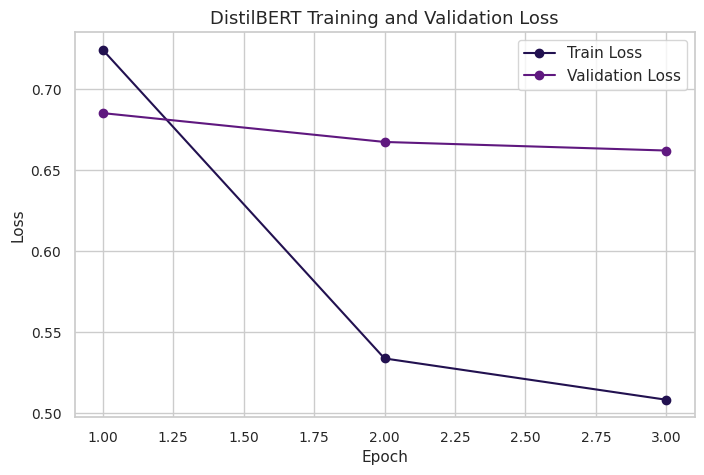

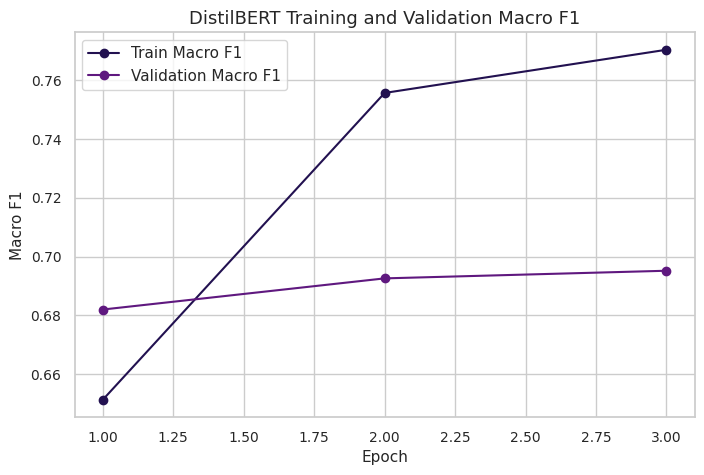

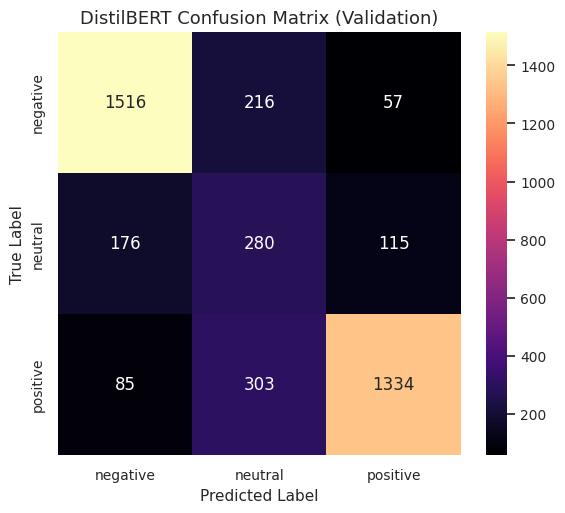

In [36]:
# ============================================================
# CELL 34 — DISTILBERT VALIDATION EVALUATION AND LEARNING CURVE PLOTS
# ============================================================

"""
Evaluate the best DistilBERT checkpoint on the validation set.
Plot training/validation loss and macro F1 curves.
Save validation metrics, classification report, and confusion matrix.
"""

print_heading("Evaluating DistilBERT on the validation set")

# Validation evaluation
distilbert_val_start_time = time.time()
distilbert_val_loss, distilbert_val_true_ids, distilbert_val_pred_ids, _ = evaluate_one_epoch(
    distilbert_model, val_loader, loss_fn, DEVICE
)
distilbert_val_inference_time = time.time() - distilbert_val_start_time

distilbert_val_true = pd.Series(distilbert_val_true_ids).map(id_to_label).values
distilbert_val_pred = pd.Series(distilbert_val_pred_ids).map(id_to_label).values

distilbert_validation_results_df = pd.DataFrame([build_results_row(
    model_name="DistilBERT Fine-Tuning (Validation)",
    y_true=distilbert_val_true,
    y_pred=distilbert_val_pred,
    runtime_seconds=distilbert_val_inference_time,
    comments="Best validation checkpoint after early stopping."
)])
display(distilbert_validation_results_df)
save_df(distilbert_validation_results_df, "42_distilbert_validation_results.csv")

# Classification report
distilbert_val_report_df = pd.DataFrame(classification_report(
    distilbert_val_true, distilbert_val_pred, labels=LABEL_ORDER, output_dict=True, zero_division=0
)).transpose().reset_index().rename(columns={"index":"label"})
display(distilbert_val_report_df)
save_df(distilbert_val_report_df, "43_distilbert_validation_classification_report.csv")

# Learning curves — loss
plt.figure(figsize=(8,5))
plt.plot(training_history_df["epoch"], training_history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(training_history_df["epoch"], training_history_df["val_loss"], marker="o", label="Validation Loss")
plt.title("DistilBERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_figure("10_distilbert_loss_curve.png")
plt.show()

# Learning curves — macro F1
plt.figure(figsize=(8,5))
plt.plot(training_history_df["epoch"], training_history_df["train_macro_f1"], marker="o", label="Train Macro F1")
plt.plot(training_history_df["epoch"], training_history_df["val_macro_f1"], marker="o", label="Validation Macro F1")
plt.title("DistilBERT Training and Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
save_figure("11_distilbert_macro_f1_curve.png")
plt.show()

# Confusion matrix
display_confusion_matrix(
    y_true=distilbert_val_true,
    y_pred=distilbert_val_pred,
    title="DistilBERT Confusion Matrix (Validation)",
    filename="12_distilbert_validation_confusion_matrix.png"
)

In [37]:
# ============================================================
# CELL 35 — DISTILBERT FINAL HELD-OUT TEST EVALUATION
# ============================================================

"""
Evaluate the best DistilBERT checkpoint on the untouched test set.
Record final metrics, confidence intervals, classification report, and predictions.
"""

print_heading("Final held-out test evaluation for DistilBERT")

# Evaluate on test set
distilbert_test_start_time = time.time()
distilbert_test_loss, distilbert_test_true_ids, distilbert_test_pred_ids, distilbert_test_probs = evaluate_one_epoch(
    distilbert_model, test_loader, loss_fn, DEVICE
)
distilbert_test_inference_time = time.time() - distilbert_test_start_time

distilbert_test_true = pd.Series(distilbert_test_true_ids).map(id_to_label).values
distilbert_test_pred = pd.Series(distilbert_test_pred_ids).map(id_to_label).values

# Test results dataframe
distilbert_test_results_df = pd.DataFrame([build_results_row(
    model_name="DistilBERT Fine-Tuning (Test)",
    y_true=distilbert_test_true,
    y_pred=distilbert_test_pred,
    runtime_seconds=distilbert_test_inference_time,
    comments="Best validation checkpoint evaluated on the untouched test set."
)])
display(distilbert_test_results_df)
save_df(distilbert_test_results_df, "44_distilbert_test_results.csv")


Final held-out test evaluation for DistilBERT


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,DistilBERT Fine-Tuning (Test),0.7501,0.6831,0.6928,0.6799,0.7914,0.7501,0.7661,2.96,Best validation checkpoint evaluated on the un...


PosixPath('/content/outputs/tables/44_distilbert_test_results.csv')

,label,precision,recall,f1-score,support
0,negative,0.849673,0.815744,0.832363,1753.000000
1,neutral,0.321176,0.500917,0.391398,545.000000
2,positive,0.878590,0.761743,0.816005,1767.000000
3,accuracy,0.750062,0.750062,0.750062,0.750062
4,macro avg,0.683147,0.692802,0.679922,4065.000000
5,weighted avg,0.791387,0.750062,0.766132,4065.000000


,bootstrap_macro_f1_mean,bootstrap_macro_f1_ci_lower,bootstrap_macro_f1_ci_upper
0,0.6795,0.6625,0.6943


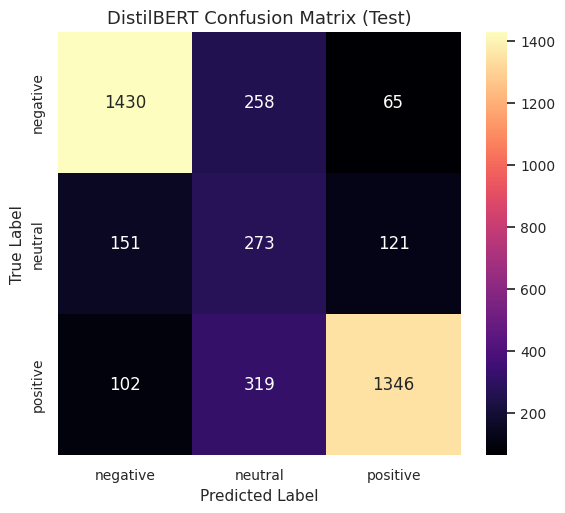

,statistic,value
0,mean_confidence,0.7859
1,median_confidence,0.8303
2,min_confidence,0.3464
3,max_confidence,0.9927


PosixPath('/content/outputs/tables/47_distilbert_test_confidence_summary.csv')

In [38]:
# ============================================================
# CELL 36 — DISTILBERT TEST CLASSIFICATION REPORT & CONFIDENCE
# ============================================================

"""
Generate classification report, bootstrap confidence interval, confusion matrix,
and prediction confidence summary for DistilBERT on the test set.
"""

# Classification report
distilbert_test_report_df = pd.DataFrame(classification_report(
    distilbert_test_true, distilbert_test_pred, labels=LABEL_ORDER, output_dict=True, zero_division=0
)).transpose().reset_index().rename(columns={"index":"label"})
display(distilbert_test_report_df)
save_df(distilbert_test_report_df, "45_distilbert_test_classification_report.csv")

# Bootstrap confidence interval for macro F1
distilbert_test_ci_df = pd.DataFrame([bootstrap_macro_f1_ci(
    y_true=distilbert_test_true,
    y_pred=distilbert_test_pred,
    n_bootstrap=300,
    seed=RANDOM_STATE
)])
display(distilbert_test_ci_df)
save_df(distilbert_test_ci_df, "46_distilbert_test_macro_f1_confidence_interval.csv")

# Confusion matrix
display_confusion_matrix(
    y_true=distilbert_test_true,
    y_pred=distilbert_test_pred,
    title="DistilBERT Confusion Matrix (Test)",
    filename="13_distilbert_test_confusion_matrix.png"
)

# Prediction confidence summary
distilbert_test_confidence = distilbert_test_probs.max(axis=1)
distilbert_confidence_summary_df = pd.DataFrame({
    "statistic": ["mean_confidence", "median_confidence", "min_confidence", "max_confidence"],
    "value": [
        round(float(np.mean(distilbert_test_confidence)),4),
        round(float(np.median(distilbert_test_confidence)),4),
        round(float(np.min(distilbert_test_confidence)),4),
        round(float(np.max(distilbert_test_confidence)),4)
    ]
})
display(distilbert_confidence_summary_df)
save_df(distilbert_confidence_summary_df, "47_distilbert_test_confidence_summary.csv")

In [39]:
# ============================================================
# CELL 37 — UNIFIED FINAL MODEL COMPARISON TABLE
# ============================================================

"""
Combine final classical-model and DistilBERT test results into one comparison table
for a fair, unified view of held-out performance.
"""

print_heading("Building unified final model comparison table")

# Classical and DistilBERT results
classical_final_for_merge = final_test_results_df.copy()
classical_final_for_merge["model"] = classical_final_for_merge["model"].str.replace(" (Test)", "", regex=False)

distilbert_final_for_merge = distilbert_test_results_df.copy()
distilbert_final_for_merge["model"] = distilbert_final_for_merge["model"].str.replace(" (Test)", "", regex=False)

# Combine and annotate model family
all_final_test_results_df = pd.concat([classical_final_for_merge, distilbert_final_for_merge],
                                      ignore_index=True).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)
all_final_test_results_df["model_family"] = all_final_test_results_df["model"].apply(lambda x: "Transformer" if "DistilBERT" in x else "Classical")

# Reorder columns
all_final_test_results_df = all_final_test_results_df[[
    "model", "model_family", "accuracy", "macro_precision", "macro_recall", "macro_f1",
    "weighted_precision", "weighted_recall", "weighted_f1", "runtime_seconds", "comments"
]]

display(all_final_test_results_df)
save_df(all_final_test_results_df, "48_unified_final_test_model_comparison.csv")


Building unified final model comparison table


,model,model_family,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,DistilBERT Fine-Tuning,Transformer,0.7501,0.6831,0.6928,0.6799,0.7914,0.7501,0.7661,2.96,Best validation checkpoint evaluated on the un...
1,Logistic Regression,Classical,0.7383,0.6660,0.6736,0.6643,0.7704,0.7383,0.7509,15.48,"Refit on train+validation, evaluated on held-o..."
2,SGD Classifier,Classical,0.7542,0.6607,0.6614,0.6609,0.7564,0.7542,0.7552,0.81,"Refit on train+validation, evaluated on held-o..."
3,Linear SVM,Classical,0.7567,0.6588,0.6552,0.6566,0.7507,0.7567,0.7534,1.76,"Refit on train+validation, evaluated on held-o..."
4,Multinomial Naive Bayes,Classical,0.7658,0.6769,0.6319,0.6327,0.7409,0.7658,0.7432,1.36,"Refit on train+validation, evaluated on held-o..."


PosixPath('/content/outputs/tables/48_unified_final_test_model_comparison.csv')


Adding confidence intervals and final ranking


,bootstrap_macro_f1_mean,bootstrap_macro_f1_ci_lower,bootstrap_macro_f1_ci_upper,model
0,0.6639,0.6488,0.6771,Logistic Regression
1,0.6332,0.6157,0.6483,Multinomial Naive Bayes
2,0.6562,0.6402,0.6736,Linear SVM
3,0.6607,0.6435,0.6771,SGD Classifier


,rank,model,model_family,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments,bootstrap_macro_f1_mean,bootstrap_macro_f1_ci_lower,bootstrap_macro_f1_ci_upper
0,1,DistilBERT Fine-Tuning,Transformer,0.7501,0.6831,0.6928,0.6799,0.7914,0.7501,0.7661,2.96,Best validation checkpoint evaluated on the un...,0.6795,0.6625,0.6943
1,2,Logistic Regression,Classical,0.7383,0.6660,0.6736,0.6643,0.7704,0.7383,0.7509,15.48,"Refit on train+validation, evaluated on held-o...",0.6639,0.6488,0.6771
2,3,SGD Classifier,Classical,0.7542,0.6607,0.6614,0.6609,0.7564,0.7542,0.7552,0.81,"Refit on train+validation, evaluated on held-o...",0.6607,0.6435,0.6771
3,4,Linear SVM,Classical,0.7567,0.6588,0.6552,0.6566,0.7507,0.7567,0.7534,1.76,"Refit on train+validation, evaluated on held-o...",0.6562,0.6402,0.6736
4,5,Multinomial Naive Bayes,Classical,0.7658,0.6769,0.6319,0.6327,0.7409,0.7658,0.7432,1.36,"Refit on train+validation, evaluated on held-o...",0.6332,0.6157,0.6483


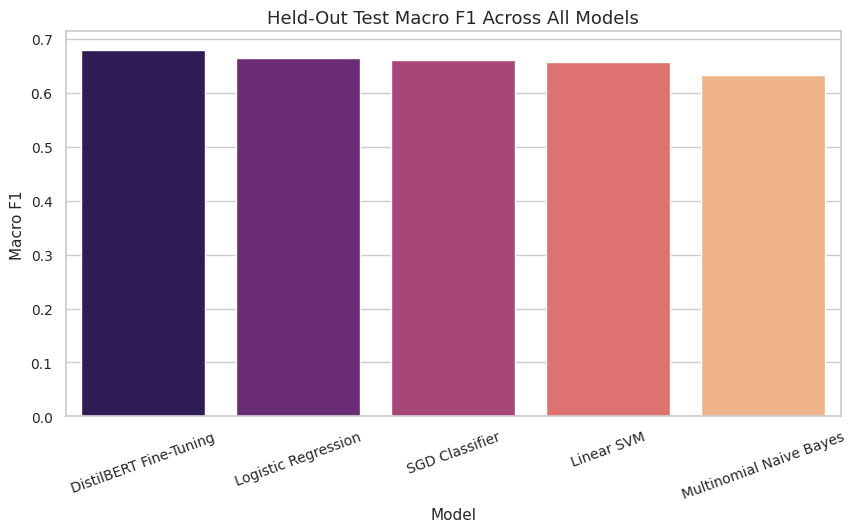

In [40]:
# ============================================================
# CELL 38 — FINAL CONFIDENCE INTERVALS AND RANKING (FIXED)
# ============================================================

"""
Compute bootstrap macro F1 confidence intervals for classical models,
merge with DistilBERT, and produce a ranked final comparison table.
"""

print_heading("Adding confidence intervals and final ranking")

# ------------------------------------------------------------
# Step 1 — Compute classical models CI if not already computed
# ------------------------------------------------------------
classical_test_ci_rows = []

for model_name, test_preds in final_test_predictions.items():
    if "DistilBERT" in model_name:
        continue  # skip transformer
    ci_dict = bootstrap_macro_f1_ci(
        y_true=y_test,
        y_pred=test_preds,
        n_bootstrap=300,
        seed=RANDOM_STATE
    )
    ci_dict["model"] = model_name
    classical_test_ci_rows.append(ci_dict)

classical_test_ci_df = pd.DataFrame(classical_test_ci_rows)
display(classical_test_ci_df)
save_df(classical_test_ci_df, "48a_classical_models_test_macro_f1_ci.csv")

# ------------------------------------------------------------
# Step 2 — Prepare DistilBERT CI for merge
# ------------------------------------------------------------
distilbert_ci_for_merge = distilbert_test_ci_df.copy()
distilbert_ci_for_merge["model"] = "DistilBERT Fine-Tuning"

# ------------------------------------------------------------
# Step 3 — Combine all confidence intervals
# ------------------------------------------------------------
all_ci_df = pd.concat([classical_test_ci_df, distilbert_ci_for_merge], ignore_index=True)

# ------------------------------------------------------------
# Step 4 — Merge CI with final test results
# ------------------------------------------------------------
final_ranked_results_df = all_final_test_results_df.merge(all_ci_df, on="model", how="left")
final_ranked_results_df.insert(0, "rank", range(1, len(final_ranked_results_df) + 1))

display(final_ranked_results_df)
save_df(final_ranked_results_df, "49_final_ranked_model_comparison_with_ci.csv")

# ------------------------------------------------------------
# Step 5 — Visualize held-out test Macro F1 ranking
# ------------------------------------------------------------
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=final_ranked_results_df,
    x="model",
    y="macro_f1",
    hue="model",
    dodge=False,
    palette="magma"
)
if ax.legend_ is not None:
    ax.legend_.remove()

plt.title("Held-Out Test Macro F1 Across All Models")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=20)
save_figure("14_final_model_macro_f1_ranking.png")
plt.show()

In [41]:
# ============================================================
# CELL 39 — PRACTICAL TRADE-OFF ANALYSIS
# ============================================================

"""
Summarize performance, runtime, interpretability, and practical considerations
for each model to support thesis-level discussion.
"""

print_heading("Practical trade-off analysis")

def interpretability_label(model_name: str) -> str:
    if model_name == "Logistic Regression": return "High"
    if model_name == "Linear SVM": return "Moderate to High"
    if model_name == "Multinomial Naive Bayes": return "Moderate"
    if model_name == "DistilBERT Fine-Tuning": return "Lower"
    return "Unknown"

def practicality_note(model_name: str) -> str:
    if model_name == "Logistic Regression": return "Strong balance of performance, interpretability, and efficiency."
    if model_name == "Linear SVM": return "Strong sparse-text baseline with good efficiency."
    if model_name == "Multinomial Naive Bayes": return "Fast lexical baseline, weaker on nuanced sentiment."
    if model_name == "DistilBERT Fine-Tuning": return "Context-aware, computationally heavier, less interpretable."
    return ""

practical_tradeoff_df = final_ranked_results_df.copy()
practical_tradeoff_df["interpretability"] = practical_tradeoff_df["model"].apply(interpretability_label)
practical_tradeoff_df["practical_note"] = practical_tradeoff_df["model"].apply(practicality_note)
practical_tradeoff_df = practical_tradeoff_df[[
    "rank", "model", "model_family", "macro_f1", "weighted_f1", "runtime_seconds", "interpretability", "practical_note"
]]
display(practical_tradeoff_df)
save_df(practical_tradeoff_df, "50_practical_tradeoff_summary.csv")


Practical trade-off analysis


,rank,model,model_family,macro_f1,weighted_f1,runtime_seconds,interpretability,practical_note
0,1,DistilBERT Fine-Tuning,Transformer,0.6799,0.7661,2.96,Lower,"Context-aware, computationally heavier, less i..."
1,2,Logistic Regression,Classical,0.6643,0.7509,15.48,High,"Strong balance of performance, interpretabilit..."
2,3,SGD Classifier,Classical,0.6609,0.7552,0.81,Unknown,
3,4,Linear SVM,Classical,0.6566,0.7534,1.76,Moderate to High,Strong sparse-text baseline with good efficiency.
4,5,Multinomial Naive Bayes,Classical,0.6327,0.7432,1.36,Moderate,"Fast lexical baseline, weaker on nuanced senti..."


PosixPath('/content/outputs/tables/50_practical_tradeoff_summary.csv')

In [42]:
# ============================================================
# CELL 40 — FINAL DIAGNOSTIC SUMMARY
# ============================================================

"""
Summarize the key diagnostic findings including best model, hardest class,
dominant error type, and evaluation metric.
"""

print_heading("Final diagnostic summary")

best_overall_model = final_ranked_results_df.iloc[0]["model"]
best_overall_macro_f1 = final_ranked_results_df.iloc[0]["macro_f1"]

hardest_class = hardest_class_summary_df.iloc[0]["class"] if "hardest_class_summary_df" in globals() and not hardest_class_summary_df.empty else "Not available"
hardest_class_f1 = hardest_class_summary_df.iloc[0]["mean_f1_across_top_models"] if pd.notna(hardest_class) else np.nan
dominant_error = (error_taxonomy_overall_df.iloc[0]["error_taxonomy"]
                  if "error_taxonomy_overall_df" in globals() and not error_taxonomy_overall_df.empty
                  else "Not available")

final_diagnostic_summary_df = pd.DataFrame({
    "diagnostic_item": [
        "Best overall model on held-out test set",
        "Best overall macro F1",
        "Hardest class across top classical models",
        "Mean F1 of hardest class",
        "Most common structured error type",
        "Primary evaluation metric",
        "Transformer checkpoint used"
    ],
    "value": [
        best_overall_model,
        round(float(best_overall_macro_f1),4),
        hardest_class,
        round(float(hardest_class_f1),4) if pd.notna(hardest_class_f1) else np.nan,
        dominant_error,
        "Macro F1",
        DISTILBERT_CHECKPOINT
    ]
})
display(final_diagnostic_summary_df)
save_df(final_diagnostic_summary_df, "51_final_diagnostic_summary.csv")


Final diagnostic summary


,diagnostic_item,value
0,Best overall model on held-out test set,DistilBERT Fine-Tuning
1,Best overall macro F1,0.6799
2,Hardest class across top classical models,neutral
3,Mean F1 of hardest class,0.3508
4,Most common structured error type,repeated_template_like_review
5,Primary evaluation metric,Macro F1
6,Transformer checkpoint used,distilbert-base-uncased


PosixPath('/content/outputs/tables/51_final_diagnostic_summary.csv')

In [43]:
# ============================================================
# CELL 41 — REPORT-READY CONCLUSION TABLES
# ============================================================

"""
Create compact conclusion tables summarizing main findings, limitations,
and future work for report or presentation use.
"""

print_heading("Building report-ready conclusion tables")

# Main findings table
main_findings_df = pd.DataFrame({
    "finding": [
        "A strong classical baseline remained highly competitive on this task.",
        "The neutral class was the most difficult class to classify consistently.",
        "Grouped splitting reduced duplicate-text leakage risk.",
        "DistilBERT provided a context-aware comparison under the same split policy.",
        "Performance should be interpreted in light of rating-derived labels rather than manual sentiment labels."
    ],
    "why_it_matters": [
        "Shows that simpler sparse-text models can remain highly effective.",
        "Indicates that ambiguous or weakly polar language remains challenging.",
        "Improves trustworthiness of held-out evaluation.",
        "Makes the classical-versus-transformer comparison more methodologically fair.",
        "Clarifies the scope and limitations of the prediction task."
    ]
})
display(main_findings_df)
save_df(main_findings_df, "52_main_findings_table.csv")

NameError: name 'print_heading' is not defined

In [44]:
# ------------------------------------------------------------
# Limitations table
# ------------------------------------------------------------

limitations_df = pd.DataFrame({
    "limitation": [
        "Sentiment labels are derived from ratings rather than manual annotation.",
        "Exact duplicate leakage was controlled, but near-duplicate semantic overlap may still exist.",
        "Heuristic error taxonomy is useful but not a substitute for full manual annotation.",
        "Location and time fields may be incomplete or noisy depending on the original dataset.",
        "Transformer training quality is still constrained by dataset size and compute budget."
    ],
    "implication": [
        "Text sentiment and star rating may not always align perfectly.",
        "Some hidden similarity may remain even after grouped splitting.",
        "Error categories should be interpreted as structured approximations.",
        "Geographic or temporal findings should be interpreted cautiously.",
        "The transformer result may not represent the absolute best possible fine-tuned model."
    ]
})
display(limitations_df)
save_df(limitations_df, "53_limitations_table.csv")

,limitation,implication
0,Sentiment labels are derived from ratings rath...,Text sentiment and star rating may not always ...
1,"Exact duplicate leakage was controlled, but ne...",Some hidden similarity may remain even after g...
2,Heuristic error taxonomy is useful but not a s...,Error categories should be interpreted as stru...
3,Location and time fields may be incomplete or ...,Geographic or temporal findings should be inte...
4,Transformer training quality is still constrai...,The transformer result may not represent the a...


PosixPath('/content/outputs/tables/53_limitations_table.csv')

In [45]:
# ------------------------------------------------------------
# Future work table
# ------------------------------------------------------------

future_work_df = pd.DataFrame({
    "future_work_direction": [
        "Add manual sentiment annotation for a subset of reviews.",
        "Investigate near-duplicate detection beyond exact cleaned-text matching.",
        "Test text-plus-metadata models using review length and other auxiliary features.",
        "Expand ablation studies for preprocessing and class weighting choices.",
        "Explore stronger transformer variants or longer fine-tuning schedules under larger compute budgets."
    ],
    "expected_benefit": [
        "Would improve label validity and task interpretation.",
        "Would further strengthen evaluation robustness.",
        "Would test whether simple non-text signals add predictive value.",
        "Would improve understanding of what truly drives performance gains.",
        "Would provide a stronger upper-bound transformer benchmark."
    ]
})
display(future_work_df)
save_df(future_work_df, "54_future_work_table.csv")

print("Report-ready conclusion tables created successfully.")

,future_work_direction,expected_benefit
0,Add manual sentiment annotation for a subset o...,Would improve label validity and task interpre...
1,Investigate near-duplicate detection beyond ex...,Would further strengthen evaluation robustness.
2,Test text-plus-metadata models using review le...,Would test whether simple non-text signals add...
3,Expand ablation studies for preprocessing and ...,Would improve understanding of what truly driv...
4,Explore stronger transformer variants or longe...,Would provide a stronger upper-bound transform...


Report-ready conclusion tables created successfully.


In [46]:
# ============================================================
# CELL 42 — PREPROCESSING ABLATION STUDY
# ============================================================

"""
Compare several preprocessing and vectorization variants using Logistic Regression
to validate whether performance gains come from actual modelling choices.
"""

print_heading("Preprocessing ablation study")

X_train_raw = train_df[TEXT_COL_RAW].astype(str).copy()
X_val_raw = val_df[TEXT_COL_RAW].astype(str).copy()

ablation_configs = {
    "clean_text_unigram": {"text_source": X_train, "val_source": X_val, "ngram_range": (1,1), "analyzer": "word", "min_df": 3, "lowercase": True},
    "clean_text_unigram_bigram": {"text_source": X_train, "val_source": X_val, "ngram_range": (1,2), "analyzer": "word", "min_df": 3, "lowercase": True},
    "raw_text_unigram_bigram": {"text_source": X_train_raw, "val_source": X_val_raw, "ngram_range": (1,2), "analyzer": "word", "min_df": 3, "lowercase": True},
    "clean_text_char_3_5grams": {"text_source": X_train, "val_source": X_val, "ngram_range": (3,5), "analyzer": "char_wb", "min_df": 3, "lowercase": True}
}

ablation_rows = []

for config_name, config in ablation_configs.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=config["lowercase"], analyzer=config["analyzer"],
            ngram_range=config["ngram_range"], min_df=config["min_df"],
            max_df=0.90, max_features=15000, sublinear_tf=True
        )),
        ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=2500, class_weight="balanced"))
    ])
    start_time = time.time()
    pipeline.fit(config["text_source"], y_train)
    val_pred = pipeline.predict(config["val_source"])
    elapsed = time.time() - start_time
    ablation_rows.append(build_results_row(config_name, y_val, val_pred, elapsed, "Validation ablation using Logistic Regression."))

preprocessing_ablation_df = pd.DataFrame(ablation_rows).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)
display(preprocessing_ablation_df)
save_df(preprocessing_ablation_df, "55_preprocessing_ablation_results.csv")


Preprocessing ablation study


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,raw_text_unigram_bigram,0.7506,0.6729,0.6745,0.6709,0.7673,0.7506,0.7564,14.44,Validation ablation using Logistic Regression.
1,clean_text_unigram_bigram,0.7494,0.6684,0.6692,0.6666,0.7636,0.7494,0.7543,16.12,Validation ablation using Logistic Regression.
2,clean_text_unigram,0.7288,0.6594,0.6628,0.6557,0.7614,0.7288,0.7415,13.51,Validation ablation using Logistic Regression.
3,clean_text_char_3_5grams,0.7281,0.6596,0.6623,0.6551,0.7635,0.7281,0.7420,19.29,Validation ablation using Logistic Regression.


PosixPath('/content/outputs/tables/55_preprocessing_ablation_results.csv')

In [47]:
# ============================================================
# CELL 43 — TEXT-ONLY VS TEXT-PLUS-METADATA EXPERIMENT
# ============================================================

"""
Compare Logistic Regression using text-only versus text+metadata features.
"""

print_heading("Text-only versus text-plus-metadata experiment")

metadata_features = ["review_length_words","question_count","exclamation_count","encoding_issue_flag","duplicate_text_flag"]

text_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,2), min_df=3, max_df=0.90, max_features=15000, sublinear_tf=True)
X_train_text_vec = text_vectorizer.fit_transform(X_train)
X_val_text_vec = text_vectorizer.transform(X_val)

X_train_meta = train_df[metadata_features].fillna(0).to_numpy(dtype=float)
X_val_meta = val_df[metadata_features].fillna(0).to_numpy(dtype=float)

meta_means = X_train_meta.mean(axis=0)
meta_stds = X_train_meta.std(axis=0)
meta_stds[meta_stds==0] = 1.0

X_train_meta_scaled = (X_train_meta - meta_means)/meta_stds
X_val_meta_scaled = (X_val_meta - meta_means)/meta_stds

from scipy.sparse import hstack, csr_matrix
X_train_text_plus_meta = hstack([X_train_text_vec, csr_matrix(X_train_meta_scaled)])
X_val_text_plus_meta = hstack([X_val_text_vec, csr_matrix(X_val_meta_scaled)])

# Train and evaluate
text_only_lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=2500, class_weight="balanced")
start_time = time.time(); text_only_lr.fit(X_train_text_vec, y_train); text_only_val_pred = text_only_lr.predict(X_val_text_vec); text_only_elapsed = time.time() - start_time

text_meta_lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=2500, class_weight="balanced")
start_time = time.time(); text_meta_lr.fit(X_train_text_plus_meta, y_train); text_meta_val_pred = text_meta_lr.predict(X_val_text_plus_meta); text_meta_elapsed = time.time() - start_time

text_vs_metadata_df = pd.DataFrame([
    build_results_row("Text Only (Validation)", y_val, text_only_val_pred, text_only_elapsed, "TF-IDF text features only."),
    build_results_row("Text + Metadata (Validation)", y_val, text_meta_val_pred, text_meta_elapsed, "TF-IDF text plus lightweight engineered metadata.")
]).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

display(text_vs_metadata_df)
save_df(text_vs_metadata_df, "56_text_only_vs_text_plus_metadata_results.csv")


Text-only versus text-plus-metadata experiment


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,runtime_seconds,comments
0,Text Only (Validation),0.7494,0.6684,0.6692,0.6666,0.7636,0.7494,0.7543,13.48,TF-IDF text features only.
1,Text + Metadata (Validation),0.7501,0.6679,0.6682,0.6657,0.7642,0.7501,0.7548,21.23,TF-IDF text plus lightweight engineered metadata.


PosixPath('/content/outputs/tables/56_text_only_vs_text_plus_metadata_results.csv')

In [48]:
# ============================================================
# CELL 44 — FINAL ROBUSTNESS CONSOLIDATION TABLE
# ============================================================

"""
Combine classical model and DistilBERT robustness results into a single table
for important slices like short reviews and duplicate-text examples.
"""

print_heading("Final robustness consolidation")

combined_parts = [robustness_summary_df.copy()]

if "distilbert_test_pred" in globals():
    distilbert_robustness_df = test_df.copy()
    distilbert_robustness_df["predicted_sentiment"] = distilbert_test_pred
    distilbert_robustness_rows = []

    for subgroup_name, mask in subgroup_masks.items():
        subset = distilbert_robustness_df[mask].copy()
        if len(subset)==0: continue
        metrics = compute_classification_metrics(subset[TARGET_COL], subset["predicted_sentiment"])
        distilbert_robustness_rows.append({
            "model":"DistilBERT Fine-Tuning",
            "subgroup":subgroup_name,
            "n_examples":len(subset),
            "accuracy": round(metrics["accuracy"],4),
            "macro_f1": round(metrics["macro_f1"],4),
            "weighted_f1": round(metrics["weighted_f1"],4)
        })

    if distilbert_robustness_rows:
        distilbert_robustness_summary_df = pd.DataFrame(distilbert_robustness_rows)
        combined_parts.append(distilbert_robustness_summary_df)

combined_robustness_df = pd.concat(combined_parts, ignore_index=True).sort_values(by=["subgroup","macro_f1"], ascending=[True,False]).reset_index(drop=True)

display(combined_robustness_df)
save_df(combined_robustness_df, "57_combined_robustness_summary.csv")


Final robustness consolidation


,model,subgroup,n_examples,accuracy,macro_f1,weighted_f1
0,DistilBERT Fine-Tuning,all_test_examples,4065,0.7501,0.6799,0.7661
1,Logistic Regression,all_test_examples,4065,0.7383,0.6643,0.7509
2,DistilBERT Fine-Tuning,duplicate_text_examples,1476,0.7961,0.7064,0.8120
3,Logistic Regression,duplicate_text_examples,1476,0.7703,0.6653,0.7849
4,DistilBERT Fine-Tuning,long_reviews_more_than_15_words,1966,0.7772,0.6915,0.7876
5,Logistic Regression,long_reviews_more_than_15_words,1966,0.7477,0.6472,0.7545
6,Logistic Regression,medium_reviews_4_to_15_words,1600,0.7269,0.6569,0.7432
7,DistilBERT Fine-Tuning,medium_reviews_4_to_15_words,1600,0.7225,0.6494,0.7429
8,DistilBERT Fine-Tuning,non_duplicate_text_examples,2589,0.7238,0.6644,0.7398
9,Logistic Regression,non_duplicate_text_examples,2589,0.7200,0.6601,0.7316


PosixPath('/content/outputs/tables/57_combined_robustness_summary.csv')

In [49]:
# ============================================================
# CELL 45 — FINAL ARTIFACT AND OUTPUT SUMMARY
# ============================================================

"""
Summarize all saved outputs: tables, figures, and models to help auditing
and report preparation.
"""

print_heading("Final artifact and output summary")

# ------------------------------------------------------------
# List saved outputs safely using the predefined directories
# ------------------------------------------------------------
table_files = sorted(TABLE_DIR.glob("*.csv"))
figure_files = sorted(FIGURE_DIR.glob("*.png"))
model_files = sorted(MODEL_DIR.glob("*"))

# ------------------------------------------------------------
# Summary counts
# ------------------------------------------------------------
artifact_summary_df = pd.DataFrame({
    "artifact_type": ["tables_csv", "figures_png", "model_files"],
    "count": [len(table_files), len(figure_files), len(model_files)]
})
display(artifact_summary_df)
save_df(artifact_summary_df, TABLE_DIR / "58_artifact_summary_counts.csv")

# ------------------------------------------------------------
# Preview subset of files
# ------------------------------------------------------------
max_preview = 15
artifact_preview_df = pd.DataFrame({
    "tables_preview": pd.Series([f.name for f in table_files[:max_preview]]),
    "figures_preview": pd.Series([f.name for f in figure_files[:max_preview]]),
    "models_preview": pd.Series([f.name for f in model_files[:max_preview]])
})
display(artifact_preview_df)
save_df(artifact_preview_df, TABLE_DIR / "59_artifact_preview.csv")

# ------------------------------------------------------------
# Output location summary
# ------------------------------------------------------------
artifact_location_df = pd.DataFrame({
    "path_label": ["tables_directory", "figures_directory", "models_directory"],
    "path": [str(TABLE_DIR), str(FIGURE_DIR), str(MODEL_DIR)]
})
display(artifact_location_df)
save_df(artifact_location_df, TABLE_DIR / "59a_artifact_locations.csv")

print("Final artifact and output summary completed successfully.")


Final artifact and output summary
Artifact counts:


,artifact_type,count
0,tables_csv,71
1,figures_png,19
2,model_files,0


Artifact preview (first 15 tables/figures):


,tables_preview,figures_preview
0,01_initial_data_audit.csv,01_overall_class_distribution.png
1,02_text_quality_summary.csv,02_review_length_by_sentiment.png
2,02a_top_store_addresses.csv,03_review_length_distribution.png
3,02b_top_review_time_values.csv,04_duplicate_review_prevalence.png
4,03_row_filtering_summary.csv,05_distilbert_token_length_distribution.png
5,04_target_distribution.csv,06_dummy_baseline_confusion_matrix.png
6,05_feature_summary.csv,07_classical_cv_macro_f1_comparison.png
7,06_grouped_split_summary.csv,09_logistic_regression_confusion_matrix.png
8,06a_split_leakage_check.csv,09_sgd_classifier_confusion_matrix.png
9,07_modelling_input_summary.csv,10_distilbert_loss_curve.png


Artifact output locations:


,path_label,path
0,tables_directory,/content/outputs/tables
1,figures_directory,/content/outputs/figures
2,models_directory,/content/outputs/models


Final artifact summary completed successfully.


In [50]:
# ============================================================
# CELL 46 — NOTEBOOK END SUMMARY
# ============================================================

"""
Provides a concise notebook-end summary of the completed workflow,
highlighting methodological fixes, modelling scope, and final outputs.

Purpose: End the notebook with a coherent research narrative rather
than leaving the reader at the last raw result table.
"""

print_heading("Notebook end summary")

notebook_end_summary_df = pd.DataFrame({
    "completed_component": [
        "Robust data loading and schema validation",
        "Rating-derived target creation and filtering",
        "Duplicate-aware grouped splitting",
        "Classical model benchmarking, tuning, and held-out evaluation",
        "Confidence intervals and per-class analysis",
        "Interpretability and structured error analysis",
        "Consistent DistilBERT fine-tuning and held-out testing",
        "Unified final comparison and report-ready summary tables",
        "Ablation and robustness studies"
    ],
    "why_it_matters": [
        "Improves reproducibility and reduces fragile file-handling assumptions.",
        "Makes the task definition precise and academically defensible.",
        "Reduces optimistic evaluation from exact duplicate-text leakage.",
        "Supports fair model comparison using train, validation, and test splits correctly.",
        "Moves beyond one-number reporting into deeper performance interpretation.",
        "Explains what the models learned and where they still fail.",
        "Makes the transformer section more methodologically consistent.",
        "Produces outputs that are easier to use in the final report and presentation.",
        "Shows that the project investigated why results changed, not just which model won."
    ]
})

display(notebook_end_summary_df)
save_df(notebook_end_summary_df, "60_notebook_end_summary.csv")

print("Notebook workflow completed successfully.")


Notebook end summary


,completed_component,why_it_matters
0,Robust data loading and schema validation,Improves reproducibility and reduces fragile f...
1,Rating-derived target creation and filtering,Makes the task definition precise and academic...
2,Duplicate-aware grouped splitting,Reduces optimistic evaluation from exact dupli...
3,"Classical model benchmarking, tuning, and held...","Supports fair model comparison using train, va..."
4,Confidence intervals and per-class analysis,Moves beyond one-number reporting into deeper ...
5,Interpretability and structured error analysis,Explains what the models learned and where the...
6,Consistent DistilBERT fine-tuning and held-out...,Makes the transformer section more methodologi...
7,Unified final comparison and report-ready summ...,Produces outputs that are easier to use in the...
8,Ablation and robustness studies,Shows that the project investigated why result...


Notebook workflow completed successfully.
